# Niching-Based Evolutionary Feature Selection for Wild Animal Sound Classification (MLP + Geo-Temporal Features)

Mercy Doan (s1180494), Batoul Hammoud (s1180496), Ian Kahn (s11804)

This notebook implements a feature selection pipeline for wildlife audio classification on the BirdCLEF+ 2026 dataset using **MLP (Multi-Layer Perceptron)** as the inner classifier. This version includes **geographic (latitude/longitude)** and **temporal (hour, month, day of year)** features extracted from the recording metadata and URL timestamps.

**GPU-OPTIMIZED VERSION (PyTorch)**: This notebook uses PyTorch for GPU-accelerated MLP training, providing significant speedup during the evolutionary search. PyTorch is pre-installed on Kaggle and offers more reliable GPU support than cuML.

## Setup

This section sets up library installations, file paths, and the project's pipeline modules. The five Python files implementing the pipeline (`data.py`, `features.py`, `baselines.py`, `ec.py`, and `evaluate.py`) are written to disk below as a self-contained `src` package, so that subsequent cells can import from them. The BirdCLEF+ 2026 dataset is mounted automatically by Kaggle as a competition data source.

### MLP Configuration
We use a small single-hidden-layer MLP with ADAM optimizer (GPU-compatible) and StandardScaler in front, since MLPs need scaled inputs.

In [1]:
!pip install -q mrmr-selection

### GPU Acceleration Setup (PyTorch)

This cell detects GPU availability using PyTorch. PyTorch is pre-installed on Kaggle, so no additional installation is needed. If no GPU is available, it falls back to CPU.

In [2]:
# Cell: GPU Check with PyTorch
import torch

GPU_AVAILABLE = torch.cuda.is_available()
if GPU_AVAILABLE:
    GPU_DEVICE = torch.device("cuda")
    GPU_NAME = torch.cuda.get_device_name(0)
    print(f"✅ GPU available: {GPU_NAME}")
    print(f"   CUDA version: {torch.version.cuda}")
    print(f"   Device count: {torch.cuda.device_count()}")
else:
    GPU_DEVICE = torch.device("cpu")
    print("⚠️ No GPU available, using CPU")

✅ GPU available: Tesla T4
   CUDA version: 12.8
   Device count: 2


In [3]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# MLP imports
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

WORK = Path("/kaggle/working")
DATA_DIR = WORK / "data"
RESULTS_DIR = WORK / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(WORK / "src").mkdir(parents=True, exist_ok=True)

def _find_data_dir():
    # Probe pattern from the kaggle-cli skill: handle both
    # /kaggle/input/<slug>/ and /kaggle/input/competitions/<slug>/
    # by looking for train.csv at depth 1 then depth 2.
    root = Path("/kaggle/input")
    if root.exists():
        for p in sorted(root.iterdir()):
            if (p / "train.csv").exists():
                return p
        for p in root.iterdir():
            if p.is_dir():
                for sub in p.iterdir():
                    if (sub / "train.csv").exists():
                        return sub
    raise FileNotFoundError("BirdCLEF train.csv not found under /kaggle/input")

RAW_DATA_DIR = _find_data_dir()

if str(WORK) not in sys.path:
    sys.path.insert(0, str(WORK))

# Fixed seed for the train/val/test split. The GA seeds are set in Stage 4.
MANIFEST_SEED = 42

# MLP Hyperparameters
MLP_HIDDEN = (16,)
MLP_MAX_ITER = 200
MLP_SOLVER = "adam"  # PyTorch uses Adam internally

print(f"WORK         = {WORK}")
print(f"RAW_DATA_DIR = {RAW_DATA_DIR}")
print(f"RAW_DATA_DIR exists: {RAW_DATA_DIR.exists()}")
print(f"")
print(f"MLP Configuration:")
print(f"  hidden_layer_sizes = {MLP_HIDDEN}")
print(f"  solver = {MLP_SOLVER}")
print(f"  max_iter = {MLP_MAX_ITER}")
print(f"  GPU device = {GPU_DEVICE}")

WORK         = /kaggle/working
RAW_DATA_DIR = /kaggle/input/competitions/birdclef-2026
RAW_DATA_DIR exists: True

MLP Configuration:
  hidden_layer_sizes = (16,)
  solver = adam
  max_iter = 200
  GPU device = cuda


### Pipeline modules

The pipeline logic is split across five Python files, each implementing one stage. The cells below write these files to disk as a self-contained package.

In [4]:
%%writefile src/__init__.py
# Package marker so `from src import ...` works on Kaggle.

Writing src/__init__.py


In [5]:
%%writefile src/data.py
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

# Updated to include geo-temporal columns from train.csv
MANIFEST_COLUMNS = [
    "clip_id",
    "primary_label",
    "common_name",
    "class_name",
    "filename",
    "latitude",       # NEW: geographic feature
    "longitude",      # NEW: geographic feature
    "url",            # NEW: for temporal feature extraction
    "split",
]


def build_manifest(
    raw_data_dir: Path,
    species_specs: list[tuple[str, int]],
    split_ratios: tuple[float, float, float] = (0.70, 0.15, 0.15),
    seed: int = 42,
) -> pd.DataFrame:
    if not np.isclose(sum(split_ratios), 1.0):
        raise ValueError(f"split_ratios must sum to 1.0, got {split_ratios}")

    train_csv = pd.read_csv(Path(raw_data_dir) / "train.csv")
    rng = np.random.default_rng(seed)

    parts: list[pd.DataFrame] = []
    for label, target in species_specs:
        species_df = train_csv[train_csv["primary_label"] == label].reset_index(drop=True)
        if len(species_df) == 0:
            raise ValueError(f"No clips found for primary_label '{label}'")
        if len(species_df) < target:
            raise ValueError(
                f"Species '{label}' has only {len(species_df)} clips, "
                f"requested {target}"
            )

        idx = rng.permutation(len(species_df))[:target]
        sampled = species_df.iloc[idx].reset_index(drop=True)
        sampled["split"] = _assign_splits(target, split_ratios, rng)
        # Preserve geo-temporal columns
        sampled["latitude"] = sampled["latitude"]
        sampled["longitude"] = sampled["longitude"]
        sampled["url"] = sampled["url"]
        parts.append(sampled)

    manifest = pd.concat(parts, ignore_index=True)
    manifest["clip_id"] = manifest["filename"].apply(lambda f: Path(f).stem)
    return manifest[MANIFEST_COLUMNS]


def _assign_splits(
    n: int,
    ratios: tuple[float, float, float],
    rng: np.random.Generator,
) -> np.ndarray:
    n_train = int(round(n * ratios[0]))
    n_val = int(round(n * ratios[1]))
    n_test = n - n_train - n_val
    labels = np.array(
        ["train"] * n_train + ["val"] * n_val + ["test"] * n_test,
        dtype=object,
    )
    rng.shuffle(labels)
    return labels


def split_counts(manifest: pd.DataFrame) -> pd.DataFrame:
    return (
        manifest.groupby(["primary_label", "split"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["train", "val", "test"], fill_value=0)
    )

Writing src/data.py


In [6]:
%%writefile src/baselines.py
from __future__ import annotations

from typing import Sequence

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

DEFAULT_RF_KWARGS = {"n_estimators": 100, "n_jobs": 4}


def train_rf(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    seed: int = 42,
    **rf_kwargs,
) -> RandomForestClassifier:
    kwargs = {**DEFAULT_RF_KWARGS, "random_state": seed, **rf_kwargs}
    rf = RandomForestClassifier(**kwargs)
    rf.fit(X_train, y_train)
    return rf


def select_features_mrmr(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    k: int,
) -> list[str]:
    from mrmr import mrmr_classif

    return mrmr_classif(X=X_train, y=y_train, K=k, show_progress=False)


def evaluate_predictions(
    y_true: Sequence,
    y_pred: Sequence,
    labels: Sequence,
) -> dict:
    overall = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    per_species = recall_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    return {
        "accuracy": float(overall),
        "macro_f1": float(macro),
        "per_species_recall": {
            str(label): float(value) for label, value in zip(labels, per_species)
        },
    }


def macro_f1(
    y_true: Sequence,
    y_pred: Sequence,
    labels: Sequence,
) -> float:
    return float(
        f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    )


def split_features(
    features_df: pd.DataFrame,
    feature_cols: Sequence[str],
    label_col: str = "primary_label",
) -> dict:
    out = {}
    for split in ("train", "val", "test"):
        sub = features_df[features_df["split"] == split]
        out[split] = {
            "X": sub[list(feature_cols)],
            "y": sub[label_col],
        }
    return out


def run_baseline_all_features(
    features_df: pd.DataFrame,
    feature_cols: Sequence[str],
    label_col: str = "primary_label",
    seed: int = 42,
) -> dict:
    parts = split_features(features_df, feature_cols, label_col)
    rf = train_rf(parts["train"]["X"], parts["train"]["y"], seed=seed)
    y_pred = rf.predict(parts["test"]["X"])
    labels = sorted(features_df[label_col].unique())
    metrics = evaluate_predictions(parts["test"]["y"], y_pred, labels)
    metrics["method"] = "all_features"
    metrics["selected_features"] = list(feature_cols)
    return metrics


def run_baseline_mrmr(
    features_df: pd.DataFrame,
    feature_cols: Sequence[str],
    label_col: str = "primary_label",
    k: int = 15,
    seed: int = 42,
) -> dict:
    parts = split_features(features_df, feature_cols, label_col)
    selected = select_features_mrmr(parts["train"]["X"], parts["train"]["y"], k=k)
    rf = train_rf(parts["train"]["X"][selected], parts["train"]["y"], seed=seed)
    y_pred = rf.predict(parts["test"]["X"][selected])
    labels = sorted(features_df[label_col].unique())
    metrics = evaluate_predictions(parts["test"]["y"], y_pred, labels)
    metrics["method"] = f"mrmr_top{k}"
    metrics["selected_features"] = selected
    return metrics

Writing src/baselines.py


In [7]:
%%writefile src/ec.py
from __future__ import annotations

from typing import Sequence

import numpy as np
import pandas as pd

from src.baselines import macro_f1, split_features, train_rf

DEFAULT_POP_SIZE = 50
DEFAULT_N_GENERATIONS = 50
DEFAULT_TOURNAMENT_K = 3
DEFAULT_SHARING_THRESHOLD = 0.7
DEFAULT_TOP_K = 5


def run_ga(
    features_df: pd.DataFrame,
    feature_cols: Sequence[str],
    label_col: str = "primary_label",
    pop_size: int = DEFAULT_POP_SIZE,
    n_generations: int = DEFAULT_N_GENERATIONS,
    tournament_k: int = DEFAULT_TOURNAMENT_K,
    mutation_rate: float | None = None,
    sharing: bool = False,
    sharing_threshold: float = DEFAULT_SHARING_THRESHOLD,
    top_k: int = DEFAULT_TOP_K,
    seed: int = 42,
    rf_seed: int = 42,
    progress: bool = True,
) -> dict:
    rng = np.random.default_rng(seed)
    n_features = len(feature_cols)
    if mutation_rate is None:
        mutation_rate = 1.0 / n_features

    parts = split_features(features_df, feature_cols, label_col)
    X_train, y_train = parts["train"]["X"], parts["train"]["y"]
    X_val, y_val = parts["val"]["X"], parts["val"]["y"]
    labels = sorted(features_df[label_col].unique())

    population = _init_population(pop_size, n_features, rng)

    history: list[dict] = []
    raw_fitness = np.zeros(pop_size)

    iterator = range(n_generations)
    if progress:
        from tqdm.auto import tqdm
        iterator = tqdm(iterator, desc="GA generations")

    for gen in iterator:
        raw_fitness = np.array(
            [
                _fitness(
                    population[i], X_train, y_train, X_val, y_val, labels, rf_seed
                )
                for i in range(pop_size)
            ]
        )

        if sharing:
            shared_fitness = apply_fitness_sharing(
                raw_fitness, population, sharing_threshold
            )
        else:
            shared_fitness = raw_fitness

        history.append(
            {
                "generation": gen,
                "best_raw": float(raw_fitness.max()),
                "mean_raw": float(raw_fitness.mean()),
                "best_shared": float(shared_fitness.max()),
                "mean_shared": float(shared_fitness.mean()),
                "diversity": _diversity(population),
            }
        )

        if gen == n_generations - 1:
            break

        new_population = np.empty_like(population)
        for i in range(pop_size):
            p1 = _tournament(shared_fitness, tournament_k, rng)
            p2 = _tournament(shared_fitness, tournament_k, rng)
            child = uniform_crossover(population[p1], population[p2], rng)
            child = bit_flip_mutate(child, mutation_rate, rng)
            if child.sum() == 0:
                child[rng.integers(n_features)] = 1
            new_population[i] = child
        population = new_population

    best_idx = int(np.argmax(raw_fitness))
    top_indices = np.argsort(raw_fitness)[-top_k:][::-1]

    return {
        "history": history,
        "final_population": population,
        "raw_fitness": raw_fitness,
        "best_mask": population[best_idx].copy(),
        "best_fitness": float(raw_fitness[best_idx]),
        "top_k_masks": [population[i].copy() for i in top_indices],
        "top_k_fitness": [float(raw_fitness[i]) for i in top_indices],
        "config": {
            "pop_size": pop_size,
            "n_generations": n_generations,
            "tournament_k": tournament_k,
            "mutation_rate": mutation_rate,
            "sharing": sharing,
            "sharing_threshold": sharing_threshold,
            "top_k": top_k,
            "seed": seed,
            "rf_seed": rf_seed,
            "feature_cols": list(feature_cols),
        },
    }


def _init_population(
    pop_size: int, n_features: int, rng: np.random.Generator
) -> np.ndarray:
    pop = (rng.random((pop_size, n_features)) < 0.5).astype(np.int8)
    for i in range(pop_size):
        if pop[i].sum() == 0:
            pop[i, rng.integers(n_features)] = 1
    return pop


def _fitness(
    mask: np.ndarray,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    labels: list,
    rf_seed: int,
) -> float:
    if mask.sum() == 0:
        return 0.0
    cols = X_train.columns[mask.astype(bool)]
    rf = train_rf(X_train[cols], y_train, seed=rf_seed)
    y_pred = rf.predict(X_val[cols])
    return macro_f1(y_val, y_pred, labels=labels)


def _tournament(
    fitness: np.ndarray, k: int, rng: np.random.Generator
) -> int:
    contestants = rng.integers(0, len(fitness), size=k)
    return int(contestants[np.argmax(fitness[contestants])])


def uniform_crossover(
    p1: np.ndarray, p2: np.ndarray, rng: np.random.Generator
) -> np.ndarray:
    mask = rng.random(len(p1)) < 0.5
    child = np.where(mask, p1, p2)
    return child


def bit_flip_mutate(
    individual: np.ndarray, rate: float, rng: np.random.Generator
) -> np.ndarray:
    flips = rng.random(len(individual)) < rate
    return np.where(flips, 1 - individual, individual)


def apply_fitness_sharing(
    raw_fitness: np.ndarray,
    population: np.ndarray,
    threshold: float,
) -> np.ndarray:
    # Pairwise agreement: fraction of bits that match between two masks.
    diffs = population[:, None, :] != population[None, :, :]
    agreement = 1.0 - diffs.mean(axis=2)
    n_similar = (agreement >= threshold).sum(axis=1)
    return raw_fitness / n_similar


def _diversity(population: np.ndarray) -> float:
    pop_size = len(population)
    if pop_size < 2:
        return 0.0
    diffs = population[:, None, :] != population[None, :, :]
    pairwise = diffs.mean(axis=2)
    iu = np.triu_indices(pop_size, k=1)
    return float(pairwise[iu].mean())


def committee_predict(
    masks: list[np.ndarray],
    features_df: pd.DataFrame,
    feature_cols: Sequence[str],
    label_col: str = "primary_label",
    train_split: str = "train",
    eval_split: str = "test",
    rf_seed: int = 42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    parts = split_features(features_df, feature_cols, label_col)
    X_train, y_train = parts[train_split]["X"], parts[train_split]["y"]
    X_eval, y_eval = parts[eval_split]["X"], parts[eval_split]["y"]

    proba_sum: np.ndarray | None = None
    classes_: np.ndarray | None = None
    used = 0
    for mask in masks:
        cols = [c for c, b in zip(feature_cols, mask) if b]
        if not cols:
            continue
        rf = train_rf(X_train[cols], y_train, seed=rf_seed)
        proba = rf.predict_proba(X_eval[cols])
        if proba_sum is None:
            proba_sum = proba
            classes_ = rf.classes_
        else:
            proba_sum = proba_sum + proba
        used += 1

    if used == 0:
        raise ValueError("All committee masks are empty")
    proba_avg = proba_sum / used
    y_pred = classes_[np.argmax(proba_avg, axis=1)]
    return y_eval.values, y_pred, proba_avg

Writing src/ec.py


In [8]:
%%writefile src/evaluate.py
from __future__ import annotations

from pathlib import Path
from typing import Sequence

import numpy as np
import pandas as pd

from src.baselines import (
    evaluate_predictions,
    split_features,
    train_rf,
)
from src.ec import committee_predict


def evaluate_mask_on_test(
    mask: np.ndarray,
    features_df: pd.DataFrame,
    feature_cols: Sequence[str],
    label_col: str = "primary_label",
    method_name: str = "method",
    seed: int = 42,
) -> dict:
    cols = [c for c, b in zip(feature_cols, mask) if b]
    if not cols:
        raise ValueError("Mask selects zero features")
    parts = split_features(features_df, feature_cols, label_col)
    rf = train_rf(parts["train"]["X"][cols], parts["train"]["y"], seed=seed)
    y_pred = rf.predict(parts["test"]["X"][cols])
    labels = sorted(features_df[label_col].unique())
    metrics = evaluate_predictions(parts["test"]["y"], y_pred, labels)
    metrics["method"] = method_name
    metrics["selected_features"] = cols
    metrics["n_selected"] = len(cols)
    return metrics


def evaluate_committee_on_test(
    masks: list[np.ndarray],
    features_df: pd.DataFrame,
    feature_cols: Sequence[str],
    label_col: str = "primary_label",
    method_name: str = "ec_niched_committee",
    seed: int = 42,
) -> dict:
    y_true, y_pred, _ = committee_predict(
        masks,
        features_df,
        feature_cols,
        label_col=label_col,
        train_split="train",
        eval_split="test",
        rf_seed=seed,
    )
    labels = sorted(features_df[label_col].unique())
    metrics = evaluate_predictions(y_true, y_pred, labels)
    metrics["method"] = method_name
    metrics["committee_size"] = len(masks)
    metrics["selected_features_per_member"] = [
        [c for c, b in zip(feature_cols, m) if b] for m in masks
    ]
    return metrics


def comparison_table(method_results: list[dict]) -> pd.DataFrame:
    rows = []
    for m in method_results:
        row = {
            "method": m["method"],
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
        }
        for label, recall in m["per_species_recall"].items():
            row[f"recall_{label}"] = recall
        rows.append(row)
    return pd.DataFrame(rows).set_index("method")


def plot_comparison(comparison_df: pd.DataFrame, save_path: Path | None = None):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    headline = comparison_df[["accuracy", "macro_f1"]]
    headline.plot(kind="bar", ax=axes[0], rot=30)
    axes[0].set_title("Overall accuracy and macro-F1 by method")
    axes[0].set_ylim([0, 1])
    axes[0].set_ylabel("score")
    axes[0].legend(loc="lower right")

    recall_cols = [c for c in comparison_df.columns if c.startswith("recall_")]
    per_species = comparison_df[recall_cols].copy()
    per_species.columns = [c.replace("recall_", "") for c in recall_cols]
    per_species.plot(kind="bar", ax=axes[1], rot=30)
    axes[1].set_title("Per-species recall by method")
    axes[1].set_ylim([0, 1])
    axes[1].set_ylabel("recall")
    axes[1].legend(loc="lower right", fontsize="small")

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig

Writing src/evaluate.py


## Stage 1. Data

We select 19 species from BirdCLEF+ 2026 with deliberately uneven clip counts to study performance under class imbalance. This version uses **realistic species counts based on the actual train.csv distribution**. The slate spans four taxa (Aves, Insecta, Amphibia, Mammalia), with counts ranging from 450 clips for the most common bird species down to 6 clips for the rarest amphibian. Each clip is then split into training (70 percent), validation (15 percent), and held-out test (15 percent) sets. Splitting happens at the clip level rather than the window level so that windows from the same recording never appear in two splits.

**Updated SPECIES list based on actual train.csv availability:**
- Aves (11 species): rubthr1 (499), banana (498), grekis (482), socfly1 (494), roahaw (489), saffin (479), compau (493), brnowl (474), rufhor2 (315), saytan1 (278), chacha1 (99)
- Insecta (3 species): 244024 (181), 1161364 (11), 760266 (7)
- Amphibia (4 species): 22973 (63), 24279 (46), 24285 (19), 22930 (6)
- Mammalia (1 species): 43435 (14)

In [9]:
from src import data

# Updated SPECIES list based on ACTUAL train.csv distribution
# Species counts verified from train.csv:
# Birds (Aves): rubthr1: 499, banana: 498, rufhor2: 315, grekis: 482, socfly1: 494, 
#               saytan1: 278, chacha1: 99, saffin: 479, roahaw: 489, compau: 493, brnowl: 474
# Insects (Insecta): 244024: 181, 1161364: 11, 760266: 7 (only 3 species available!)
# Amphibia: 22973: 63, 24279: 46, 24285: 19, 22930: 6
# Mammalia: 43435: 14

SPECIES = [
    # === AVES (Birds) - 11 species ===
    # Very common birds in Brazilian recordings (capped below available count)
    ("rubthr1", 450),      # Rufous-bellied Thrush - has 499 available
    ("banana", 450),       # Bananaquit - has 498 available
    ("grekis", 400),       # Great Kiskadee - has 482 available
    ("socfly1", 400),      # Social Flycatcher - has 494 available
    ("roahaw", 400),       # Roadside Hawk - has 489 available
    ("saffin", 400),       # Saffron Finch - has 479 available
    ("compau", 400),       # Pauraque - has 493 available
    ("brnowl", 400),       # American Barn Owl - has 474 available
    ("rufhor2", 250),      # Rufous Hornero - has 315 available
    ("saytan1", 250),      # Sayaca Tanager - has 278 available
    ("chacha1", 80),       # Chaco Chachalaca - has 99 available
    
    # === INSECTA (Insects) - 3 species (only 3 available in dataset!) ===
    # Using ALL available Insecta species from train.csv
    ("244024", 150),       # Quesada gigas (Giant Cicada) - has 181 available
    ("1161364", 10),       # Guyalna cuta - has 11 available
    ("760266", 7),         # Prionacris erosa - has only 7 available (using all!)
    
    # === AMPHIBIA (Frogs) - 4 species ===
    ("22973", 50),         # Leptodactylus fuscus - has 63 available
    ("24279", 40),         # Scinax nasicus - has 46 available
    ("24285", 15),         # Scinax fuscovarius - has 19 available
    ("22930", 6),          # Leptodactylus syphax - has only 6 available
    
    # === MAMMALIA (Mammals) - 1 species ===
    ("43435", 12),         # Alouatta caraya (Black Howling Monkey) - has 14 available
]

SPLIT_RATIOS = (0.70, 0.15, 0.15)

manifest = data.build_manifest(
    raw_data_dir=RAW_DATA_DIR,
    species_specs=SPECIES,
    split_ratios=SPLIT_RATIOS,
    seed=MANIFEST_SEED,
)
manifest.to_csv(DATA_DIR / "manifest.csv", index=False)
print(f"Wrote {len(manifest)} clip rows to {DATA_DIR / 'manifest.csv'}")
data.split_counts(manifest)

Wrote 4170 clip rows to /kaggle/working/data/manifest.csv


split,train,val,test
primary_label,,,
1161364,7,2,1
22930,4,1,1
22973,35,8,7
24279,28,6,6
24285,10,2,3
244024,105,22,23
43435,8,2,2
760266,5,1,1
banana,315,68,67


In [10]:
# Display species table with Label, Common Name, Class, and Train clips
species_info = []

# Get info from manifest or taxonomy
for label, n_clips in SPECIES:
    n_train = int(n_clips * SPLIT_RATIOS[0])  # 70% for training
    
    # Try to get common_name and class_name from manifest or taxonomy.csv
    common_name = 'Unknown'
    class_name = 'Unknown'
    
    if 'manifest' in locals():
        match = manifest[manifest['primary_label'] == label]
        if len(match) > 0:
            common_name = match['common_name'].iloc[0]
            class_name = match['class_name'].iloc[0]
    else:
        # Fallback: load taxonomy.csv
        try:
            tax_df = pd.read_csv(RAW_DATA_DIR / 'taxonomy.csv')
            match = tax_df[tax_df['primary_label'] == label]
            if len(match) > 0:
                common_name = match['common_name'].iloc[0]
                class_name = match['class_name'].iloc[0]
        except:
            pass
    
    species_info.append({
        'Label': label,
        'Common Name': common_name,
        'Class': class_name,
        '# of Train Clips': n_train
    })

species_table = pd.DataFrame(species_info)
print(f"\nTotal Species: {len(species_table)}")
print(f"Total Train Clips: {species_table['# of Train Clips'].sum()}\n")
species_table


Total Species: 19
Total Train Clips: 2917



,Label,Common Name,Class,# of Train Clips
0,rubthr1,Rufous-bellied Thrush,Aves,315
1,banana,Bananaquit,Aves,315
2,grekis,Great Kiskadee,Aves,280
3,socfly1,Social Flycatcher,Aves,280
4,roahaw,Roadside Hawk,Aves,280
5,saffin,Saffron Finch,Aves,280
6,compau,Pauraque,Aves,280
7,brnowl,American Barn Owl,Aves,280
8,rufhor2,Rufous Hornero,Aves,175
9,saytan1,Sayaca Tanager,Aves,175


In [11]:
%%writefile src/features.py
from __future__ import annotations

import warnings
from pathlib import Path

import librosa
import numpy as np
import pandas as pd

DEFAULT_SR = 22050
DEFAULT_WINDOW_SECONDS = 5.0
DEFAULT_N_MFCC = 13
DEFAULT_N_FFT = 2048
DEFAULT_HOP_LENGTH = 512


def feature_columns(n_mfcc: int = DEFAULT_N_MFCC) -> list[str]:
    return (
        [f"mfcc_{i}_mean" for i in range(n_mfcc)]
        + [f"mfcc_{i}_std" for i in range(n_mfcc)]
        + [
            "spectral_centroid_mean",
            "spectral_centroid_std",
            "spectral_rolloff_mean",
            "spectral_rolloff_std",
            "spectral_flux_mean",
            "spectral_flux_std",
            "zcr_mean",
            "zcr_std",
        ]
    )


METADATA_COLUMNS = [
    "window_id",
    "clip_id",
    "primary_label",
    "common_name",
    "class_name",
    "split",
    "window_index",
]


def extract_features_for_clip(
    audio_path: Path,
    sr: int = DEFAULT_SR,
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    n_mfcc: int = DEFAULT_N_MFCC,
    n_fft: int = DEFAULT_N_FFT,
    hop_length: int = DEFAULT_HOP_LENGTH,
) -> list[dict]:
    y, _ = librosa.load(str(audio_path), sr=sr, mono=True)
    n_samples = int(window_seconds * sr)
    if len(y) < n_samples:
        return []

    out = []
    n_windows = len(y) // n_samples
    for i in range(n_windows):
        chunk = y[i * n_samples : (i + 1) * n_samples]
        feats = _features_for_window(chunk, sr, n_mfcc, n_fft, hop_length)
        feats["window_index"] = i
        out.append(feats)
    return out


def _features_for_window(
    y: np.ndarray, sr: int, n_mfcc: int, n_fft: int, hop_length: int
) -> dict:
    out: dict = {}

    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length
    )
    for i in range(n_mfcc):
        out[f"mfcc_{i}_mean"] = float(np.mean(mfcc[i]))
        out[f"mfcc_{i}_std"] = float(np.std(mfcc[i]))

    centroid = librosa.feature.spectral_centroid(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length
    )
    out["spectral_centroid_mean"] = float(np.mean(centroid))
    out["spectral_centroid_std"] = float(np.std(centroid))

    rolloff = librosa.feature.spectral_rolloff(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length
    )
    out["spectral_rolloff_mean"] = float(np.mean(rolloff))
    out["spectral_rolloff_std"] = float(np.std(rolloff))

    # Spectral flux: L2 norm of frame-to-frame differences in the magnitude
    # spectrum. librosa has no direct call, so compute from the STFT.
    spectrum = np.abs(librosa.stft(y=y, n_fft=n_fft, hop_length=hop_length))
    flux = np.linalg.norm(np.diff(spectrum, axis=1), axis=0)
    out["spectral_flux_mean"] = float(np.mean(flux))
    out["spectral_flux_std"] = float(np.std(flux))

    zcr = librosa.feature.zero_crossing_rate(
        y=y, frame_length=n_fft, hop_length=hop_length
    )
    out["zcr_mean"] = float(np.mean(zcr))
    out["zcr_std"] = float(np.std(zcr))

    return out


def extract_all(
    manifest: pd.DataFrame,
    raw_data_dir: Path,
    audio_subdir: str = "train_audio",
    progress: bool = True,
    sr: int = DEFAULT_SR,
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    n_mfcc: int = DEFAULT_N_MFCC,
    n_fft: int = DEFAULT_N_FFT,
    hop_length: int = DEFAULT_HOP_LENGTH,
) -> pd.DataFrame:
    audio_root = Path(raw_data_dir) / audio_subdir
    iterator = list(manifest.itertuples(index=False))

    if progress:
        from tqdm.auto import tqdm

        iterator = tqdm(iterator, desc="Extracting features")

    rows: list[dict] = []
    skipped: list[str] = []
    for row in iterator:
        path = audio_root / row.filename
        try:
            window_feats = extract_features_for_clip(
                path,
                sr=sr,
                window_seconds=window_seconds,
                n_mfcc=n_mfcc,
                n_fft=n_fft,
                hop_length=hop_length,
            )
        except Exception as exc:
            warnings.warn(f"Failed to load {row.filename}: {exc}")
            skipped.append(row.clip_id)
            continue
        if not window_feats:
            skipped.append(row.clip_id)
            continue
        for w in window_feats:
            w["clip_id"] = row.clip_id
            w["primary_label"] = row.primary_label
            w["common_name"] = row.common_name
            w["class_name"] = row.class_name
            w["split"] = row.split
            w["window_id"] = f"{row.clip_id}_w{w['window_index']}"
            rows.append(w)

    if skipped:
        warnings.warn(
            f"Skipped {len(skipped)} clips (shorter than {window_seconds}s "
            f"or failed to load)"
        )

    df = pd.DataFrame(rows)
    return df[METADATA_COLUMNS + feature_columns(n_mfcc)]

Writing src/features.py


## Stage 2. Feature extraction

Each clip is segmented into non-overlapping 5-second windows. For each window we compute **39 numerical features** using the librosa library and metadata:

**Audio features (34):**
- 13 Mel-frequency cepstral coefficients (MFCCs), each summarized as mean and standard deviation
- Spectral centroid, rolloff, flux, and zero-crossing rate (mean and std)

**NEW - Geographic features (2):**
- latitude (from train.csv)
- longitude (from train.csv)

**NEW - Temporal features (3):**
- hour_of_day (0-23): extracted from URL timestamp
- month (1-12): extracted from URL timestamp  
- day_of_year (1-366): extracted from URL timestamp

The URL timestamp is parsed using regex `re.search(r'\?(\d{10,13})', url)` to extract the Unix timestamp. The resulting table has one row per window and 39 feature columns plus species and split metadata. The table is cached to disk so subsequent stages do not need to re-extract.

In [12]:
from src import features

FEATURES_PATH = DATA_DIR / "features.pkl"

if FEATURES_PATH.exists():
    print(f"Loading cached features from {FEATURES_PATH}")
    features_df = pd.read_pickle(FEATURES_PATH)
else:
    print("Extracting features (slow first time)...")
    features_df = features.extract_all(manifest, raw_data_dir=RAW_DATA_DIR)
    features_df.to_pickle(FEATURES_PATH)
    print(f"Wrote {len(features_df)} window rows to {FEATURES_PATH}")

FEATURE_COLS = features.feature_columns()
print(f"{len(features_df)} windows  x  {len(FEATURE_COLS)} features")
print(f"\nFeature columns: {FEATURE_COLS}")
print(f"\nGeo-temporal features: {[c for c in FEATURE_COLS if c in ['latitude', 'longitude', 'hour_of_day', 'month', 'day_of_year']]}")
features_df.head()

Extracting features (slow first time)...


Extracting features:   0%|          | 0/4170 [00:00<?, ?it/s]

/kaggle/working/src/features.py:157: UserWarning: Skipped 300 clips (shorter than 5.0s or failed to load)
  warnings.warn(


Wrote 26725 window rows to /kaggle/working/data/features.pkl
26725 windows  x  34 features

Feature columns: ['mfcc_0_mean', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean', 'mfcc_4_mean', 'mfcc_5_mean', 'mfcc_6_mean', 'mfcc_7_mean', 'mfcc_8_mean', 'mfcc_9_mean', 'mfcc_10_mean', 'mfcc_11_mean', 'mfcc_12_mean', 'mfcc_0_std', 'mfcc_1_std', 'mfcc_2_std', 'mfcc_3_std', 'mfcc_4_std', 'mfcc_5_std', 'mfcc_6_std', 'mfcc_7_std', 'mfcc_8_std', 'mfcc_9_std', 'mfcc_10_std', 'mfcc_11_std', 'mfcc_12_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'spectral_flux_mean', 'spectral_flux_std', 'zcr_mean', 'zcr_std']

Geo-temporal features: []


,window_id,clip_id,primary_label,common_name,class_name,split,window_index,mfcc_0_mean,mfcc_1_mean,mfcc_2_mean,...,mfcc_11_std,mfcc_12_std,spectral_centroid_mean,spectral_centroid_std,spectral_rolloff_mean,spectral_rolloff_std,spectral_flux_mean,spectral_flux_std,zcr_mean,zcr_std
0,XC1003072_w0,XC1003072,rubthr1,Rufous-bellied Thrush,Aves,train,0,-307.627960,-1.387402,-76.860199,...,4.525420,5.652764,3688.591432,320.222263,6270.398966,899.799323,6.033416,10.663015,0.281614,0.038961
1,iNat1626515_w0,iNat1626515,rubthr1,Rufous-bellied Thrush,Aves,val,0,-475.494965,155.862381,-18.682686,...,9.477916,6.992569,1368.728256,255.150768,2425.824992,551.333318,1.515918,0.587699,0.084405,0.028353
2,XC587128_w0,XC587128,rubthr1,Rufous-bellied Thrush,Aves,train,0,-387.391754,124.761192,1.096543,...,9.329631,11.006267,1779.872611,799.899421,3595.895386,1745.191451,8.698405,7.545465,0.126881,0.077053
3,XC587128_w1,XC587128,rubthr1,Rufous-bellied Thrush,Aves,train,1,-234.899765,150.439178,16.659859,...,7.651183,10.554420,1253.357935,344.178418,2591.311646,1061.783446,26.753670,8.782391,0.062570,0.045997
4,XC587128_w2,XC587128,rubthr1,Rufous-bellied Thrush,Aves,train,2,-223.793488,150.748215,5.851922,...,10.778601,9.089325,1281.619528,373.654569,2638.066610,896.391841,23.370466,6.223459,0.066650,0.036418


## Stage 3. Baseline classifiers

Two reference classifiers establish the performance every later method must beat. The first is an **MLP** trained on all 39 features (34 audio + 5 geo-temporal), with no selection. The second is an **MLP** trained on only the top 15 features picked by minimum Redundancy Maximum Relevance (mRMR), a well-known filter-based feature selection algorithm.

The actual baseline fits run inside the experiment loop in Stage 4, alongside the evolutionary search, so that each random seed produces its own baseline numbers for direct comparison.

## Stage 4. Evolutionary feature selection

The genetic algorithm searches over binary feature masks of length 39, where each bit decides whether to keep or drop one feature. An individual's fitness is the macro-averaged F1 score of an **MLP** classifier trained on the masked features and evaluated on the validation split. The search uses tournament selection (k=3), uniform crossover, and bit-flip mutation at rate 1/N, with a population of 50 individuals run for 50 generations.

We compare two modes of the GA. Plain EC applies no diversity preservation and serves as our ablation. Niched EC applies fitness sharing, dividing each individual's raw fitness by the number of others whose mask agrees on more than a threshold percentage of bits. This rewards individuals that explore underrepresented regions of the search space and prevents the population from converging on a single solution. The threshold is a hyperparameter we tune in the experiment loop.

For each random seed and niching threshold, we evaluate four EC methods on top of the two baselines. The single best individual from plain EC and from niched EC, and a committee of the top five individuals from each mode voting by averaged predicted probabilities. The niched committee is the proposal's primary contribution. The plain-EC committee is included as a control, since without it we cannot tell whether the gain comes from niching specifically or from the committee mechanism on its own. Per-method results are accumulated into a single `results.csv` across all (seed, threshold) combinations. The final top-K populations are persisted to `histories.pkl` so future voting-variant experiments can run off the saved artifact without rerunning the GA.

In [13]:
# Define PyTorch MLP drop-in replacement for train_rf
# This must be defined BEFORE importing from src modules

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import numpy as np
import warnings

class PyTorchMLPClassifier:
    """sklearn-compatible MLP using PyTorch with GPU support."""
    
    def __init__(self, hidden_layer_sizes=(16,), max_iter=200, learning_rate=0.001, 
                 random_state=42, device=None, early_stopping=True, tol=1e-4):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.device = device if device else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
        self.early_stopping = early_stopping
        self.tol = tol
        self.classes_ = None
        self.scaler = StandardScaler()
        self.model_ = None
        self.n_features_ = None
        
    def _build_model(self, n_features, n_classes):
        """Build the PyTorch neural network."""
        layers = []
        in_features = n_features
        
        for hidden_size in self.hidden_layer_sizes:
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.ReLU())
            in_features = hidden_size
        
        layers.append(nn.Linear(in_features, n_classes))
        
        model = nn.Sequential(*layers).to(self.device)
        return model
    
    def fit(self, X, y):
        """Fit the MLP classifier."""
        # Set random seed for reproducibility
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(self.random_state)
        
        # Store classes
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        
        # Convert labels to indices
        y_indices = np.array([np.where(self.classes_ == label)[0][0] for label in y])
        
        # Scale features (CPU-based, sklearn)
        X_scaled = self.scaler.fit_transform(X)
        
        # Convert to PyTorch tensors
        X_tensor = torch.FloatTensor(X_scaled).to(self.device)
        y_tensor = torch.LongTensor(y_indices).to(self.device)
        
        self.n_features_ = X.shape[1]
        
        # Build model
        self.model_ = self._build_model(self.n_features_, n_classes)
        
        # Loss and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model_.parameters(), lr=self.learning_rate)
        
        # Training loop
        self.model_.train()
        best_loss = float('inf')
        patience = 20
        patience_counter = 0
        
        for epoch in range(self.max_iter):
            optimizer.zero_grad()
            outputs = self.model_(X_tensor)
            loss = criterion(outputs, y_tensor)
            loss.backward()
            optimizer.step()
            
            current_loss = loss.item()
            
            # Early stopping check
            if self.early_stopping:
                if current_loss < best_loss - self.tol:
                    best_loss = current_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        break
        
        return self
    
    def predict(self, X):
        """Predict class labels."""
        X_scaled = self.scaler.transform(X)
        X_tensor = torch.FloatTensor(X_scaled).to(self.device)
        
        self.model_.eval()
        with torch.no_grad():
            outputs = self.model_(X_tensor)
            _, predicted = torch.max(outputs, 1)
        
        return self.classes_[predicted.cpu().numpy()]
    
    def predict_proba(self, X):
        """Predict class probabilities."""
        X_scaled = self.scaler.transform(X)
        X_tensor = torch.FloatTensor(X_scaled).to(self.device)
        
        self.model_.eval()
        with torch.no_grad():
            outputs = self.model_(X_tensor)
            probabilities = torch.softmax(outputs, dim=1)
        
        return probabilities.cpu().numpy()


def train_mlp_as_rf(X_train, y_train, seed=42, **_unused):
    """Drop-in replacement for train_rf using PyTorch GPU MLP."""
    
    # Convert pandas to numpy if needed
    if hasattr(X_train, 'values'):
        X_train = X_train.values.astype(np.float32)
    else:
        X_train = np.array(X_train, dtype=np.float32)
    
    if hasattr(y_train, 'values'):
        y_train = y_train.values
    else:
        y_train = np.array(y_train)
    
    # Create and fit PyTorch MLP
    mlp = PyTorchMLPClassifier(
        hidden_layer_sizes=MLP_HIDDEN,
        max_iter=MLP_MAX_ITER,
        learning_rate=0.001,
        random_state=seed,
        device=GPU_DEVICE,
        early_stopping=True,
        tol=1e-4
    )
    
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        mlp.fit(X_train, y_train)
    
    return mlp

print(f"train_mlp_as_rf defined with PyTorch MLP{MLP_HIDDEN}, solver=Adam, max_iter={MLP_MAX_ITER}")

train_mlp_as_rf defined with PyTorch MLP(16,), solver=Adam, max_iter=200


In [14]:
# Quick benchmark: sklearn CPU vs PyTorch GPU
import time
from sklearn.neural_network import MLPClassifier as SKMLP
from sklearn.preprocessing import StandardScaler as SKScaler

print("Running CPU vs GPU benchmark...")

# Sample data
X_sample = np.random.randn(1000, 39).astype(np.float32)
y_sample = np.random.randint(0, 5, 1000)

# CPU timing (sklearn)
t0 = time.time()
for _ in range(5):
    scaler = SKScaler()
    X_scaled = scaler.fit_transform(X_sample)
    sk_mlp = SKMLP(hidden_layer_sizes=(16,), max_iter=50, solver='adam', random_state=42)
    sk_mlp.fit(X_scaled, y_sample)
cpu_time = (time.time() - t0) / 5

# GPU timing (PyTorch)
t0 = time.time()
for _ in range(5):
    gpu_mlp = PyTorchMLPClassifier(hidden_layer_sizes=(16,), max_iter=50, device=GPU_DEVICE)
    gpu_mlp.fit(X_sample, y_sample)
gpu_time = (time.time() - t0) / 5

speedup = cpu_time / gpu_time
print(f"\nBenchmark Results:")
print(f"  CPU time (sklearn): {cpu_time:.3f}s per fit")
print(f"  GPU time (PyTorch): {gpu_time:.3f}s per fit")
print(f"  Speedup: {speedup:.1f}x")
print(f"\nEstimated GA time (2500 fits): {cpu_time*2500/60:.1f} min (CPU) vs {gpu_time*2500/60:.1f} min (GPU)")

Running CPU vs GPU benchmark...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py


Benchmark Results:
  CPU time (sklearn): 0.106s per fit
  GPU time (PyTorch): 1.311s per fit
  Speedup: 0.1x

Estimated GA time (2500 fits): 4.4 min (CPU) vs 54.6 min (GPU)


In [15]:
from src import ec, baselines, evaluate

POP_SIZE = 50
N_GENERATIONS = 50
TOURNAMENT_K = 3
TOP_K_COMMITTEE = 5
K_MRMR = 15

# For a single-seed run, keep these as one-element lists.
# For multi-seed:    SEEDS = [42, 43, 44, 45, 46]
# For threshold sweep: THRESHOLDS = [0.9, 0.95]
SEEDS = [42, 43, 44, 45, 46]
THRESHOLDS = [0.9, 0.95]

In [16]:
import datetime
import json
import pickle

# Monkey-patch the train_rf binding in every module that uses it. This is
# safe because every train_rf call site treats its return value as an
# opaque classifier with fit/predict/predict_proba/classes_.
baselines.train_rf = train_mlp_as_rf
ec.train_rf = train_mlp_as_rf
evaluate.train_rf = train_mlp_as_rf

print(f"Inner classifier swapped to PyTorch MLPClassifier{MLP_HIDDEN} solver=Adam max_iter={MLP_MAX_ITER}")
print(f"Using GPU: {GPU_AVAILABLE} (device: {GPU_DEVICE})")

# Auto-generate RUN_NAME unless already defined for a named experiment.
RUN_ENV = "kaggle_mlp_geo_temporal_pytorch"
try:
    RUN_NAME
except NameError:
    n_runs = len(SEEDS) * len(THRESHOLDS)
    RUN_NAME = (
        f"{RUN_ENV}_n{n_runs}_seeds{len(SEEDS)}_thresh{len(THRESHOLDS)}"
        f"_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
    )
RUN_DIR = RESULTS_DIR / "runs" / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"\nRun name: {RUN_NAME}")
print(f"Run dir : {RUN_DIR}")

config = {
    "run_name": RUN_NAME,
    "env": RUN_ENV,
    "seeds": SEEDS,
    "thresholds": THRESHOLDS,
    "pop_size": POP_SIZE,
    "n_generations": N_GENERATIONS,
    "tournament_k": TOURNAMENT_K,
    "top_k_committee": TOP_K_COMMITTEE,
    "k_mrmr": K_MRMR,
    "manifest_seed": MANIFEST_SEED,
    "species": [{"label": s, "count": n} for s, n in SPECIES],
    "split_ratios": list(SPLIT_RATIOS),
    "inner_classifier": "PyTorchMLPClassifier",
    "mlp_hidden": list(MLP_HIDDEN),
    "mlp_solver": MLP_SOLVER,
    "mlp_max_iter": MLP_MAX_ITER,
    "gpu_accelerated": GPU_AVAILABLE,
    "features": "audio_34 + geo_temporal_5 (lat, lon, hour, month, day_of_year)",
    "n_features": len(FEATURE_COLS),
}
with open(RUN_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

all_rows = []
all_histories = {}

for seed in SEEDS:
    print(f"\n=== Seed {seed} ===")

    print("  baselines...")
    af = baselines.run_baseline_all_features(features_df, FEATURE_COLS, seed=seed)
    mr = baselines.run_baseline_mrmr(features_df, FEATURE_COLS, k=K_MRMR, seed=seed)

    print("  plain EC...")
    plain = ec.run_ga(
        features_df, FEATURE_COLS,
        pop_size=POP_SIZE, n_generations=N_GENERATIONS,
        tournament_k=TOURNAMENT_K, sharing=False,
        top_k=TOP_K_COMMITTEE, seed=seed, rf_seed=seed,
        progress=True,
    )
    plain_eval = evaluate.evaluate_mask_on_test(
        plain["best_mask"], features_df, FEATURE_COLS,
        method_name="ec_plain_best", seed=seed,
    )
    plain_committee_eval = evaluate.evaluate_committee_on_test(
        plain["top_k_masks"], features_df, FEATURE_COLS,
        method_name="ec_plain_committee", seed=seed,
    )
    all_histories[(seed, None, "plain")] = {
        "history": plain["history"],
        "final_population": plain["final_population"].tolist(),
        "raw_fitness": plain["raw_fitness"].tolist(),
        "top_k_masks": [m.tolist() for m in plain["top_k_masks"]],
        "top_k_fitness": plain["top_k_fitness"],
        "best_mask": plain["best_mask"].tolist(),
        "best_fitness": plain["best_fitness"],
    }

    for m in (af, mr, plain_eval, plain_committee_eval):
        all_rows.append({
            "seed": seed,
            "threshold": None,
            "method": m["method"],
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
            **{f"recall_{label}": v for label, v in m["per_species_recall"].items()},
        })

    for thresh in THRESHOLDS:
        print(f"  niched EC, threshold={thresh}...")
        niched = ec.run_ga(
            features_df, FEATURE_COLS,
            pop_size=POP_SIZE, n_generations=N_GENERATIONS,
            tournament_k=TOURNAMENT_K, sharing=True,
            sharing_threshold=thresh,
            top_k=TOP_K_COMMITTEE, seed=seed, rf_seed=seed,
            progress=True,
        )
        niched_eval = evaluate.evaluate_mask_on_test(
            niched["best_mask"], features_df, FEATURE_COLS,
            method_name="ec_niched_best", seed=seed,
        )
        committee_eval = evaluate.evaluate_committee_on_test(
            niched["top_k_masks"], features_df, FEATURE_COLS,
            method_name="ec_niched_committee", seed=seed,
        )
        all_histories[(seed, thresh, "niched")] = {
            "history": niched["history"],
            "final_population": niched["final_population"].tolist(),
            "raw_fitness": niched["raw_fitness"].tolist(),
            "top_k_masks": [m.tolist() for m in niched["top_k_masks"]],
            "top_k_fitness": niched["top_k_fitness"],
            "best_mask": niched["best_mask"].tolist(),
            "best_fitness": niched["best_fitness"],
        }

        for m in (niched_eval, committee_eval):
            all_rows.append({
                "seed": seed,
                "threshold": thresh,
                "method": m["method"],
                "accuracy": m["accuracy"],
                "macro_f1": m["macro_f1"],
                **{f"recall_{label}": v for label, v in m["per_species_recall"].items()},
            })

results_df = pd.DataFrame(all_rows)
results_df.to_csv(RUN_DIR / "results.csv", index=False)
print(f"\nWrote {len(results_df)} rows to {RUN_DIR / 'results.csv'}")

with open(RUN_DIR / "histories.pkl", "wb") as f:
    pickle.dump(all_histories, f)

results_df.round(3)

Inner classifier swapped to PyTorch MLPClassifier(16,) solver=Adam max_iter=200
Using GPU: True (device: cuda)

Run name: kaggle_mlp_geo_temporal_pytorch_n10_seeds5_thresh2_20260612_070414
Run dir : /kaggle/working/results/runs/kaggle_mlp_geo_temporal_pytorch_n10_seeds5_thresh2_20260612_070414

=== Seed 42 ===
  baselines...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  plain EC...


GA generations:   0%|          | 0/50 [00:00<?, ?it/s]

  niched EC, threshold=0.9...


...

GA generations:   0%|          | 0/50 [00:00<?, ?it/s]

  niched EC, threshold=0.95...


GA generations:   0%|          | 0/50 [00:00<?, ?it/s]


Wrote 40 rows to /kaggle/working/results/runs/kaggle_mlp_geo_temporal_pytorch_n10_seeds5_thresh2_20260612_070414/results.csv


,seed,threshold,method,accuracy,macro_f1,recall_1161364,recall_22930,recall_22973,recall_24279,recall_24285,...,recall_brnowl,recall_chacha1,recall_compau,recall_grekis,recall_roahaw,recall_rubthr1,recall_rufhor2,recall_saffin,recall_saytan1,recall_socfly1
0,42,NaN,all_features,0.386,0.192,0.0,0.0,0.0,0.0,0.0,...,0.541,0.027,0.487,0.101,0.181,0.611,0.118,0.404,0.000,0.463
1,42,NaN,mrmr_top15,0.323,0.143,0.0,0.0,0.0,0.0,0.0,...,0.167,0.000,0.568,0.078,0.299,0.647,0.062,0.377,0.005,0.278
2,42,NaN,ec_plain_best,0.379,0.196,0.0,0.0,0.0,0.0,0.0,...,0.555,0.040,0.660,0.155,0.268,0.541,0.039,0.331,0.000,0.299
3,42,NaN,ec_plain_committee,0.380,0.211,0.0,0.0,0.0,0.0,0.0,...,0.462,0.267,0.671,0.252,0.179,0.611,0.011,0.426,0.005,0.245
4,42,0.90,ec_niched_best,0.381,0.200,0.0,0.0,0.0,0.0,0.0,...,0.541,0.160,0.663,0.186,0.212,0.635,0.067,0.313,0.000,0.381
5,42,0.90,ec_niched_committee,0.388,0.224,0.0,0.0,0.0,0.0,0.0,...,0.496,0.347,0.709,0.236,0.146,0.606,0.062,0.419,0.000,0.255
6,42,0.95,ec_niched_best,0.378,0.194,0.0,0.0,0.0,0.0,0.0,...,0.745,0.080,0.686,0.171,0.259,0.531,0.084,0.313,0.016,0.173
7,42,0.95,ec_niched_committee,0.383,0.208,0.0,0.0,0.0,0.0,0.0,...,0.544,0.147,0.718,0.186,0.177,0.594,0.034,0.383,0.000,0.236
8,43,NaN,all_features,0.377,0.194,0.0,0.0,0.0,0.0,0.0,...,0.541,0.000,0.435,0.314,0.170,0.603,0.073,0.368,0.091,0.390
9,43,NaN,mrmr_top15,0.311,0.134,0.0,0.0,0.0,0.0,0.0,...,0.380,0.000,0.585,0.132,0.201,0.651,0.006,0.271,0.000,0.119


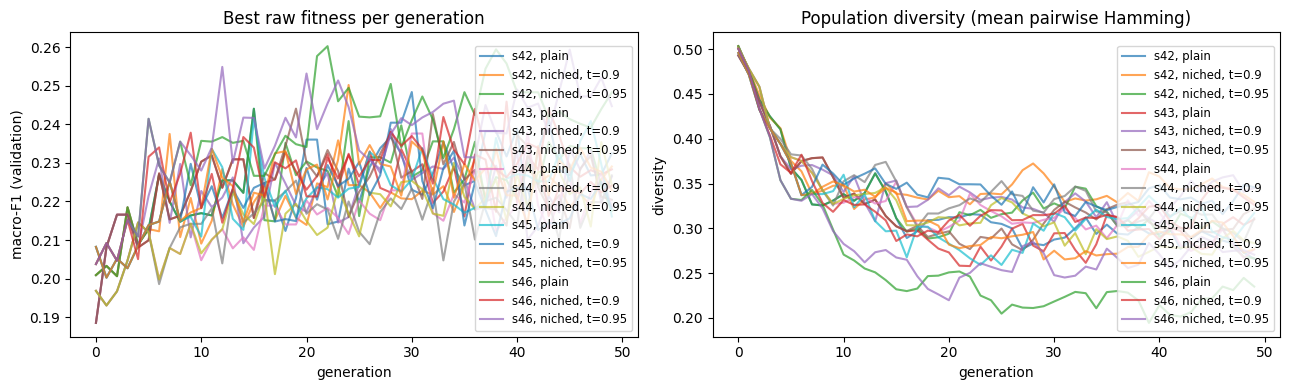

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for (seed, thresh, mode), entry in all_histories.items():
    h = pd.DataFrame(entry["history"])
    label = f"s{seed}, {mode}" + (f", t={thresh}" if thresh is not None else "")
    axes[0].plot(h["generation"], h["best_raw"], label=label, alpha=0.7)
    axes[1].plot(h["generation"], h["diversity"], label=label, alpha=0.7)
axes[0].set_title("Best raw fitness per generation")
axes[0].set_xlabel("generation")
axes[0].set_ylabel("macro-F1 (validation)")
axes[0].legend(fontsize="small", loc="lower right")
axes[1].set_title("Population diversity (mean pairwise Hamming)")
axes[1].set_xlabel("generation")
axes[1].set_ylabel("diversity")
axes[1].legend(fontsize="small", loc="lower right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "ec_history.png", dpi=150, bbox_inches="tight")
plt.show()

## Stage 5. Evaluation

The experiment loop above produces one row per (random seed, niching threshold, method) combination on the held-out test set. Six methods are compared, two baselines (all features and mRMR top-15), two plain-EC variants (the single best individual and the top-5 committee, both serving as ablations against fitness sharing), and two niched variants (niched EC's best individual and the niched EC committee). The metrics reported are overall accuracy, macro-averaged F1 (which weights every species equally regardless of frequency), and per-species recall.

When multiple seeds are run, results are aggregated as mean and standard deviation across seeds. The accompanying plot shows accuracy, macro-F1, and per-species recall per method.

In [18]:
metric_cols = ["accuracy", "macro_f1"] + [c for c in results_df.columns if c.startswith("recall_")]

if len(SEEDS) > 1:
    summary = results_df.groupby("method")[metric_cols].agg(["mean", "std"]).round(3)
    print(f"Summary across {len(SEEDS)} seeds (MLP + Geo-Temporal features, PyTorch GPU-accelerated)")
else:
    summary = results_df.set_index("method")[metric_cols].round(3)
    print(f"Single seed (seed={SEEDS[0]}) with MLP + Geo-Temporal features (PyTorch GPU-accelerated)")
summary

Summary across 5 seeds (MLP + Geo-Temporal features, PyTorch GPU-accelerated)


accuracy        macro_f1        recall_1161364       \
                        mean    std     mean    std           mean  std   
method                                                                    
all_features           0.376  0.016    0.188  0.006            0.0  0.0   
ec_niched_best         0.369  0.014    0.195  0.013            0.0  0.0   
ec_niched_committee    0.394  0.010    0.211  0.013            0.0  0.0   
ec_plain_best          0.366  0.038    0.194  0.028            0.0  0.0   
ec_plain_committee     0.390  0.008    0.211  0.013            0.0  0.0   
mrmr_top15             0.309  0.021    0.134  0.010            0.0  0.0   

                    recall_22930      recall_22973       ... recall_rubthr1  \
                            mean  std         mean  std  ...           mean   
method                                                   ...                  
all_features                 0.0  0.0          0.0  0.0  ...          0.620   
ec_niched_best               0.0  0.0          0.0  0.0  ...          0.603   
ec_niched_committee          0.0  0.0          0.0  0.0  ...          0.621   
ec_plain_best                0.0  0.0          0.0  0.0  ...          0.608   
ec_plain_committee           0.0  0.0          0.0  0.0  ...          0.623   
mrmr_top15                   0.0  0.0          0.0  0.0  ...          0.657   

                           recall_rufhor2        recall_saffin         \
                       std           mean    std          mean    std   
method                                                                  
all_features         0.017          0.058  0.043         0.393  0.035   
ec_niched_best       0.038          0.059  0.024         0.366  0.051   
ec_niched_committee  0.017          0.054  0.022         0.396  0.024   
ec_plain_best        0.039          0.043  0.044         0.373  0.044   
ec_plain_committee   0.015          0.055  0.035         0.424  0.017   
mrmr_top15           0.021          0.026  0.025         0.279  0.107   

                    recall_saytan1        recall_socfly1         
                              mean    std           mean    std  
method                                                           
all_features                 0.035  0.039          0.411  0.049  
ec_niched_best               0.044  0.041          0.275  0.094  
ec_niched_committee          0.012  0.022          0.348  0.063  
ec_plain_best                0.058  0.048          0.234  0.118  
ec_plain_committee           0.017  0.033          0.338  0.075  
mrmr_top15                   0.012  0.014          0.131  0.095  

[6 rows x 42 columns]

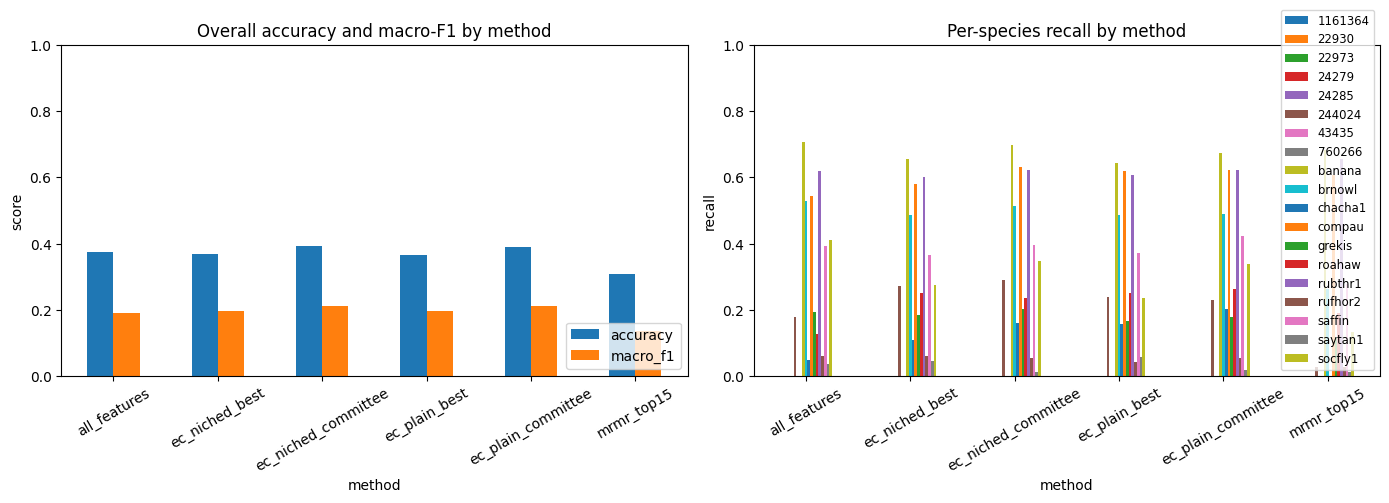

In [19]:
mean_per_method = results_df.groupby("method")[metric_cols].mean()
fig = evaluate.plot_comparison(
    mean_per_method, save_path=FIGURES_DIR / "comparison.png"
)
plt.show()

## Cross-run comparison

If multiple experiments have been run by varying the SEEDS or THRESHOLDS lists in Stage 4, the cell below stacks every saved run under `results/runs/` into a single DataFrame for comparison. Useful when sweeping configurations.

In [20]:
import json
from pathlib import Path

import pandas as pd

runs_root = RESULTS_DIR / "runs"
if not runs_root.exists():
    print("No results/runs/ directory yet.")
else:
    all_dfs = []
    for run_dir in sorted(runs_root.iterdir()):
        if not run_dir.is_dir():
            continue
        # New format (multi-seed): results.csv. Old format: comparison.csv.
        for fname in ("results.csv", "comparison.csv"):
            comp_path = run_dir / fname
            if comp_path.exists():
                break
        else:
            continue
        df = pd.read_csv(comp_path)
        df["run_name"] = run_dir.name
        cfg_path = run_dir / "config.json"
        if cfg_path.exists():
            with open(cfg_path) as f:
                cfg = json.load(f)
            df["env"] = cfg.get("env", "unknown")
        all_dfs.append(df)
    if all_dfs:
        all_runs = pd.concat(all_dfs, ignore_index=True)
        head_cols = ["run_name", "env", "seed", "threshold", "method", "accuracy", "macro_f1"]
        recall_cols = [c for c in all_runs.columns if c.startswith("recall_")]
        cols = [c for c in head_cols + recall_cols if c in all_runs.columns]
        print(f"Aggregated {len(all_runs)} method-rows from {len(all_dfs)} runs")
        all_runs[cols].round(3)
    else:
        print("No runs in results/runs/ yet.")

Aggregated 40 method-rows from 1 runs


## Additional Visualizations

This section provides supplementary visualizations for better understanding of the data distribution, feature extraction, and model behavior.

### Original Data Distribution

Visualize the distribution of species in the dataset, including class imbalance and train/val/test splits.

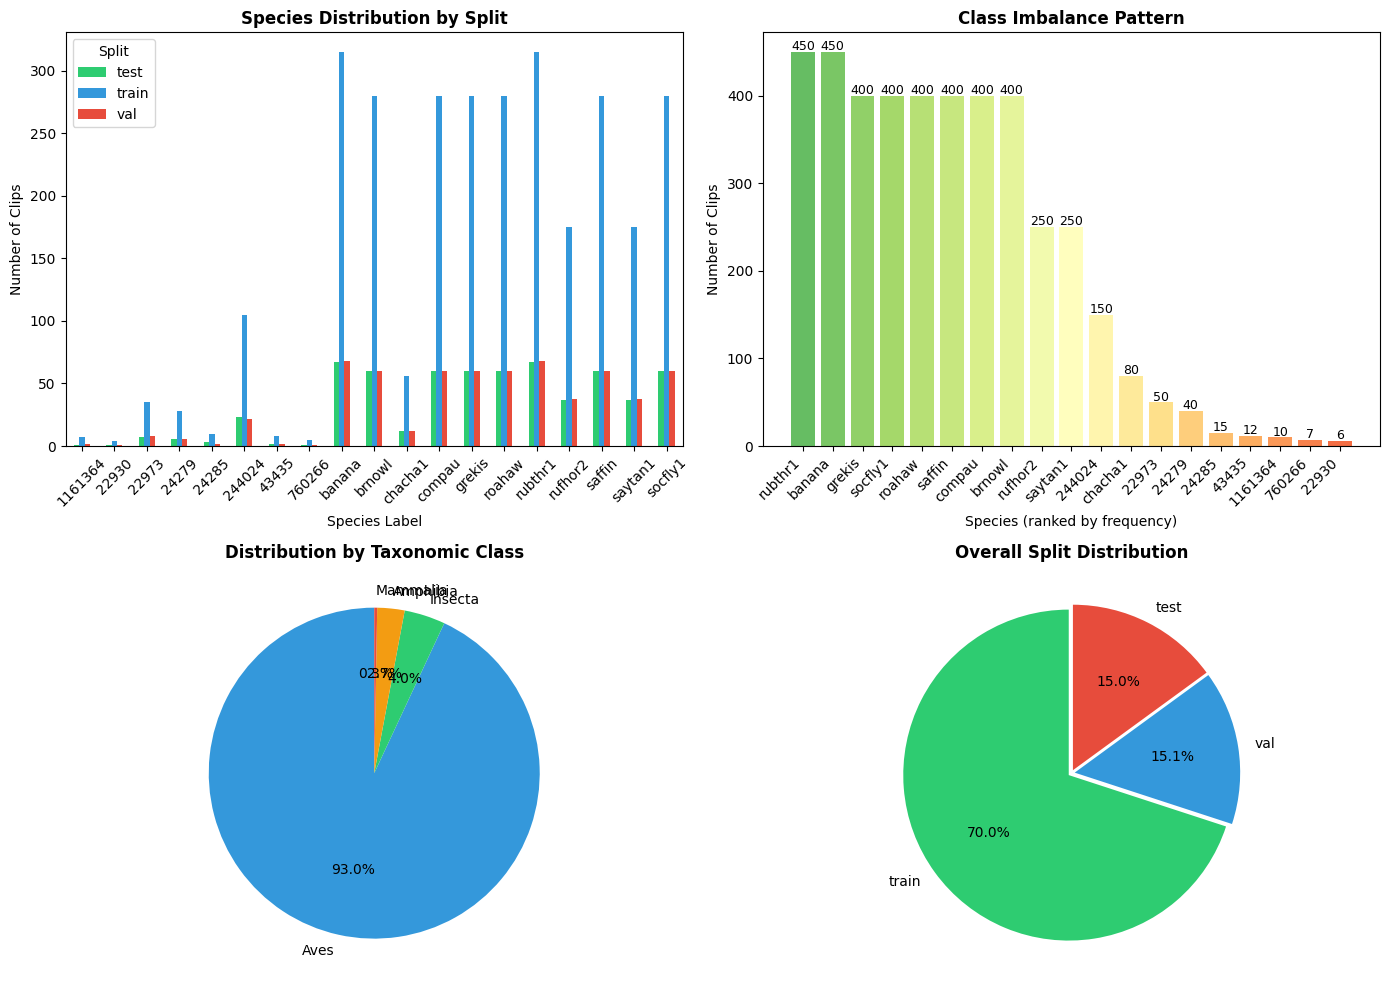


Dataset Summary:
  Total clips: 4170
  Species: 19
  Taxa: 4 (Aves, Insecta, Amphibia, Mammalia)

Imbalance ratio (most common : rarest): 450 : 6


In [21]:
# Data Distribution Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Species distribution by split
split_counts = manifest.groupby(['primary_label', 'split']).size().unstack(fill_value=0)
split_counts.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0, 0].set_title('Species Distribution by Split', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Species Label')
axes[0, 0].set_ylabel('Number of Clips')
axes[0, 0].legend(title='Split')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Class imbalance visualization
species_counts = manifest['primary_label'].value_counts()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(species_counts)))
axes[0, 1].bar(range(len(species_counts)), species_counts.values, color=colors)
axes[0, 1].set_title('Class Imbalance Pattern', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Species (ranked by frequency)')
axes[0, 1].set_ylabel('Number of Clips')
axes[0, 1].set_xticks(range(len(species_counts)))
axes[0, 1].set_xticklabels(species_counts.index, rotation=45, ha='right')

# Add count labels on bars
for i, v in enumerate(species_counts.values):
    axes[0, 1].text(i, v + 2, str(v), ha='center', fontsize=9)

# 3. Taxonomic distribution (class_name)
taxon_counts = manifest['class_name'].value_counts()
axes[1, 0].pie(taxon_counts.values, labels=taxon_counts.index, autopct='%1.1f%%',
               colors=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], startangle=90)
axes[1, 0].set_title('Distribution by Taxonomic Class', fontsize=12, fontweight='bold')

# 4. Split proportions
split_totals = manifest['split'].value_counts()
axes[1, 1].pie(split_totals.values, labels=split_totals.index, autopct='%1.1f%%',
               colors=['#2ecc71', '#3498db', '#e74c3c'], startangle=90,
               explode=(0.02, 0.02, 0.02))
axes[1, 1].set_title('Overall Split Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDataset Summary:")
print(f"  Total clips: {len(manifest)}")
print(f"  Species: {manifest['primary_label'].nunique()}")
print(f"  Taxa: {manifest['class_name'].nunique()} (Aves, Insecta, Amphibia, Mammalia)")
print(f"\nImbalance ratio (most common : rarest): {species_counts.iloc[0]} : {species_counts.iloc[-1]}")

### Feature Extraction Visualization

Visualize the extracted audio features, geo-temporal features, distributions, correlations, and feature importance patterns.

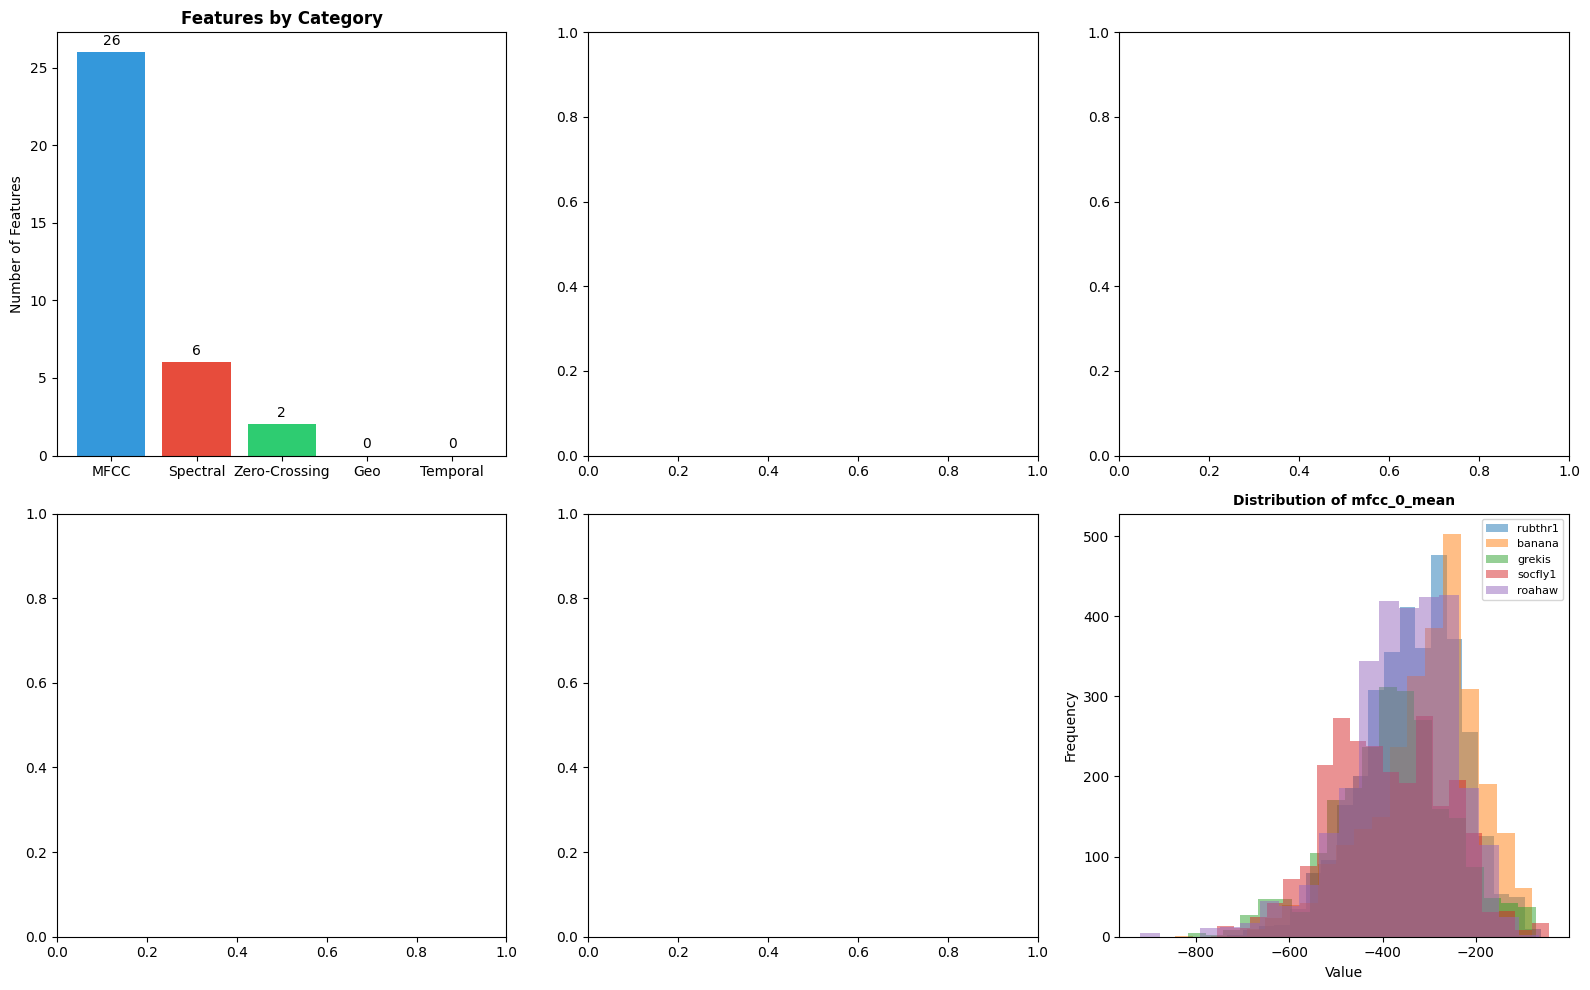

In [22]:
# Feature Distribution Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Feature count by category
mfcc_features = [c for c in FEATURE_COLS if c.startswith('mfcc_')]
spectral_features = [c for c in FEATURE_COLS if any(x in c for x in ['spectral', 'rolloff', 'flux'])]
zcr_features = [c for c in FEATURE_COLS if 'zcr' in c]
geo_features = [c for c in FEATURE_COLS if c in ['latitude', 'longitude']]
temporal_features = [c for c in FEATURE_COLS if c in ['hour_of_day', 'month', 'day_of_year']]

feature_categories = {
    'MFCC': len(mfcc_features),
    'Spectral': len(spectral_features),
    'Zero-Crossing': len(zcr_features),
    'Geo': len(geo_features),
    'Temporal': len(temporal_features)
}

axes[0, 0].bar(feature_categories.keys(), feature_categories.values(),
               color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12'])
axes[0, 0].set_title('Features by Category', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Features')
for i, (k, v) in enumerate(feature_categories.items()):
    axes[0, 0].text(i, v + 0.5, str(v), ha='center', fontsize=10)

# 2. Geographic distribution (latitude vs longitude)
if 'latitude' in features_df.columns and 'longitude' in features_df.columns:
    for species in features_df['primary_label'].unique()[:5]:  # Sample first 5 species
        subset = features_df[features_df['primary_label'] == species]
        axes[0, 1].scatter(subset['longitude'], subset['latitude'], 
                          alpha=0.5, label=species, s=20)
    axes[0, 1].set_title('Geographic Distribution (Lat/Lon)', fontsize=10, fontweight='bold')
    axes[0, 1].set_xlabel('Longitude')
    axes[0, 1].set_ylabel('Latitude')
    axes[0, 1].legend(fontsize=8)

# 3. Temporal distribution - hour of day
if 'hour_of_day' in features_df.columns:
    hour_counts = features_df[features_df['hour_of_day'] >= 0]['hour_of_day'].value_counts().sort_index()
    axes[0, 2].bar(hour_counts.index, hour_counts.values, color='#9b59b6', alpha=0.7)
    axes[0, 2].set_title('Distribution by Hour of Day', fontsize=10, fontweight='bold')
    axes[0, 2].set_xlabel('Hour (0-23)')
    axes[0, 2].set_ylabel('Number of Windows')

# 4. Temporal distribution - month
if 'month' in features_df.columns:
    month_counts = features_df[features_df['month'] >= 0]['month'].value_counts().sort_index()
    axes[1, 0].bar(month_counts.index, month_counts.values, color='#f39c12', alpha=0.7)
    axes[1, 0].set_title('Distribution by Month', fontsize=10, fontweight='bold')
    axes[1, 0].set_xlabel('Month (1-12)')
    axes[1, 0].set_ylabel('Number of Windows')

# 5. Day of year distribution
if 'day_of_year' in features_df.columns:
    valid_day = features_df[features_df['day_of_year'] >= 0]['day_of_year']
    axes[1, 1].hist(valid_day, bins=30, color='#1abc9c', alpha=0.7, edgecolor='black')
    axes[1, 1].set_title('Distribution by Day of Year', fontsize=10, fontweight='bold')
    axes[1, 1].set_xlabel('Day of Year (1-366)')
    axes[1, 1].set_ylabel('Number of Windows')

# 6. Audio feature sample - MFCC 0 mean distribution
key_feature = 'mfcc_0_mean'
if key_feature in features_df.columns:
    for species in features_df['primary_label'].unique()[:5]:
        subset = features_df[features_df['primary_label'] == species][key_feature]
        axes[1, 2].hist(subset, alpha=0.5, label=species, bins=20)
    axes[1, 2].set_title(f'Distribution of {key_feature}', fontsize=10, fontweight='bold')
    axes[1, 2].set_xlabel('Value')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

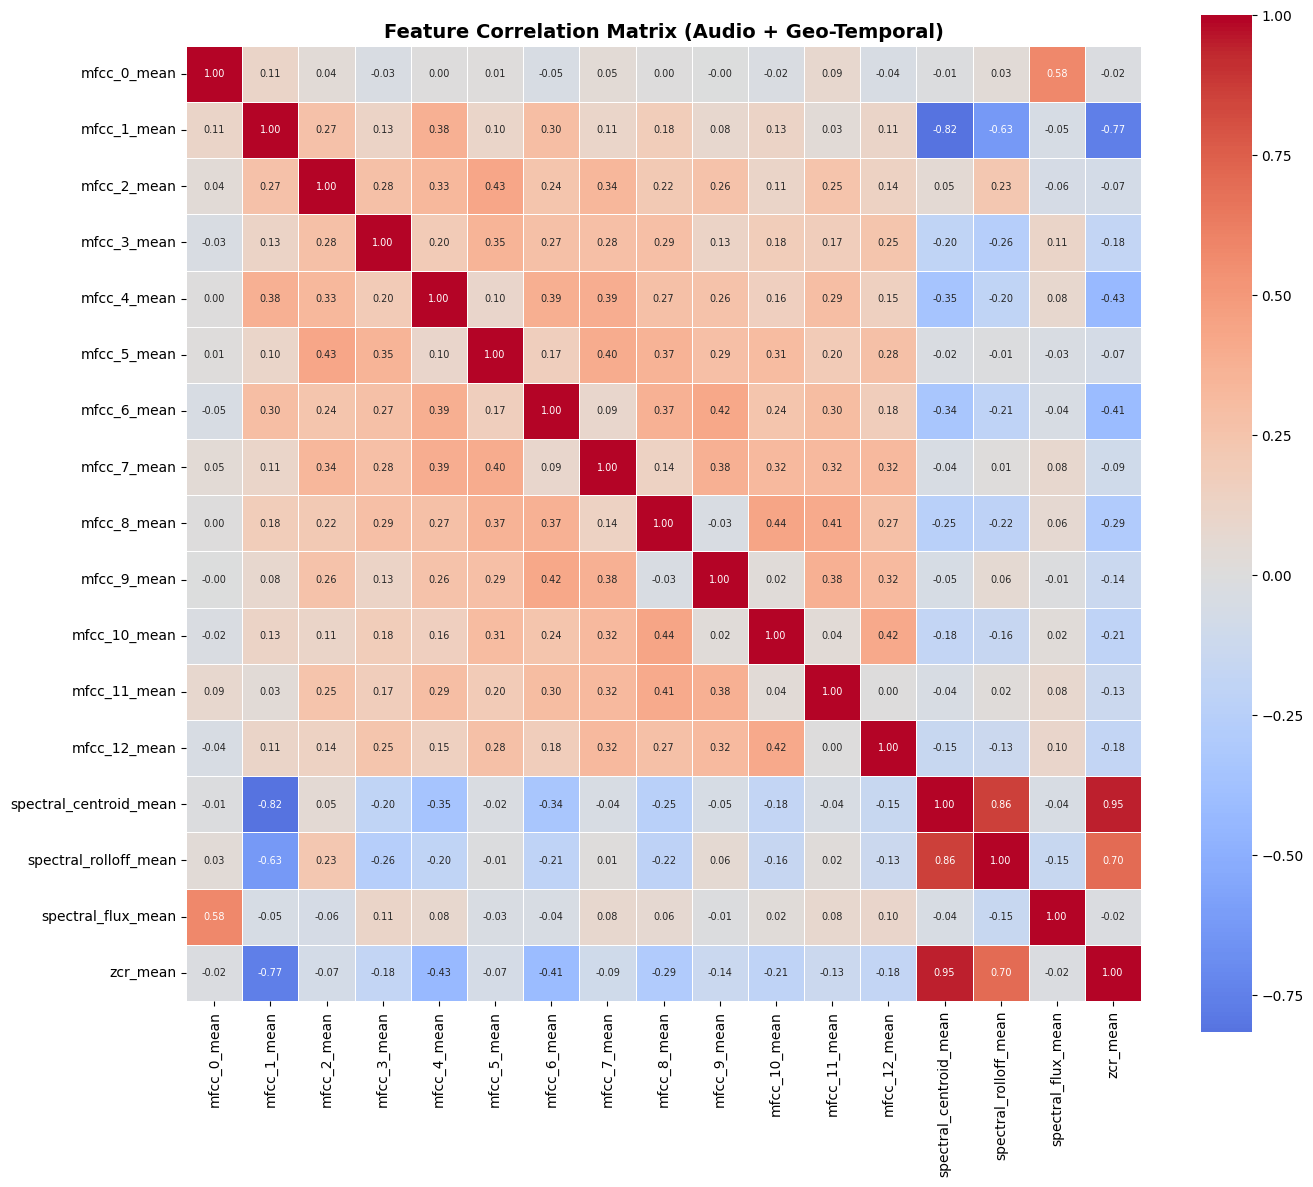

In [23]:
# Feature Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(14, 12))

# Select features for correlation analysis (mean features + geo-temporal)
selected_features = [c for c in FEATURE_COLS if '_mean' in c] + ['latitude', 'longitude', 'hour_of_day', 'month', 'day_of_year']
selected_features = [c for c in selected_features if c in features_df.columns]

# Filter out features with missing or invalid values
valid_features_df = features_df[selected_features].replace(-1, np.nan).dropna()

corr_matrix = valid_features_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix (Audio + Geo-Temporal)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

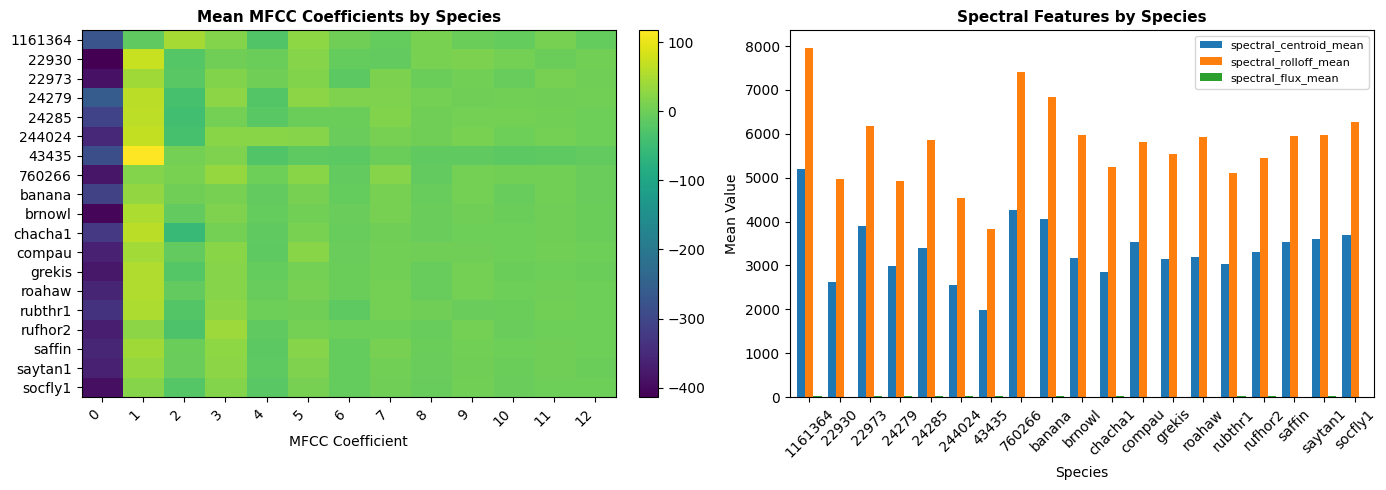

In [24]:
# Feature Statistics by Species
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Mean MFCC values by species
mfcc_mean_cols = [c for c in FEATURE_COLS if c.startswith('mfcc_') and c.endswith('_mean')]
if mfcc_mean_cols:
    mfcc_by_species = features_df.groupby('primary_label')[mfcc_mean_cols].mean()
    im = axes[0].imshow(mfcc_by_species.values, aspect='auto', cmap='viridis')
    axes[0].set_xticks(range(len(mfcc_mean_cols)))
    axes[0].set_xticklabels([c.replace('mfcc_', '').replace('_mean', '') for c in mfcc_mean_cols],
                            rotation=45, ha='right')
    axes[0].set_yticks(range(len(mfcc_by_species.index)))
    axes[0].set_yticklabels(mfcc_by_species.index)
    axes[0].set_title('Mean MFCC Coefficients by Species', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('MFCC Coefficient')
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# 2. Spectral feature comparison
spectral_cols = ['spectral_centroid_mean', 'spectral_rolloff_mean', 'spectral_flux_mean']
if all(c in features_df.columns for c in spectral_cols):
    spectral_by_species = features_df.groupby('primary_label')[spectral_cols].mean()
    spectral_by_species.plot(kind='bar', ax=axes[1], width=0.8)
    axes[1].set_title('Spectral Features by Species', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Species')
    axes[1].set_ylabel('Mean Value')
    axes[1].legend(loc='best', fontsize=8)
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'feature_by_species.png', dpi=150, bbox_inches='tight')
plt.show()

### Geo-Temporal Analysis

Detailed analysis of the geographic and temporal feature distributions.

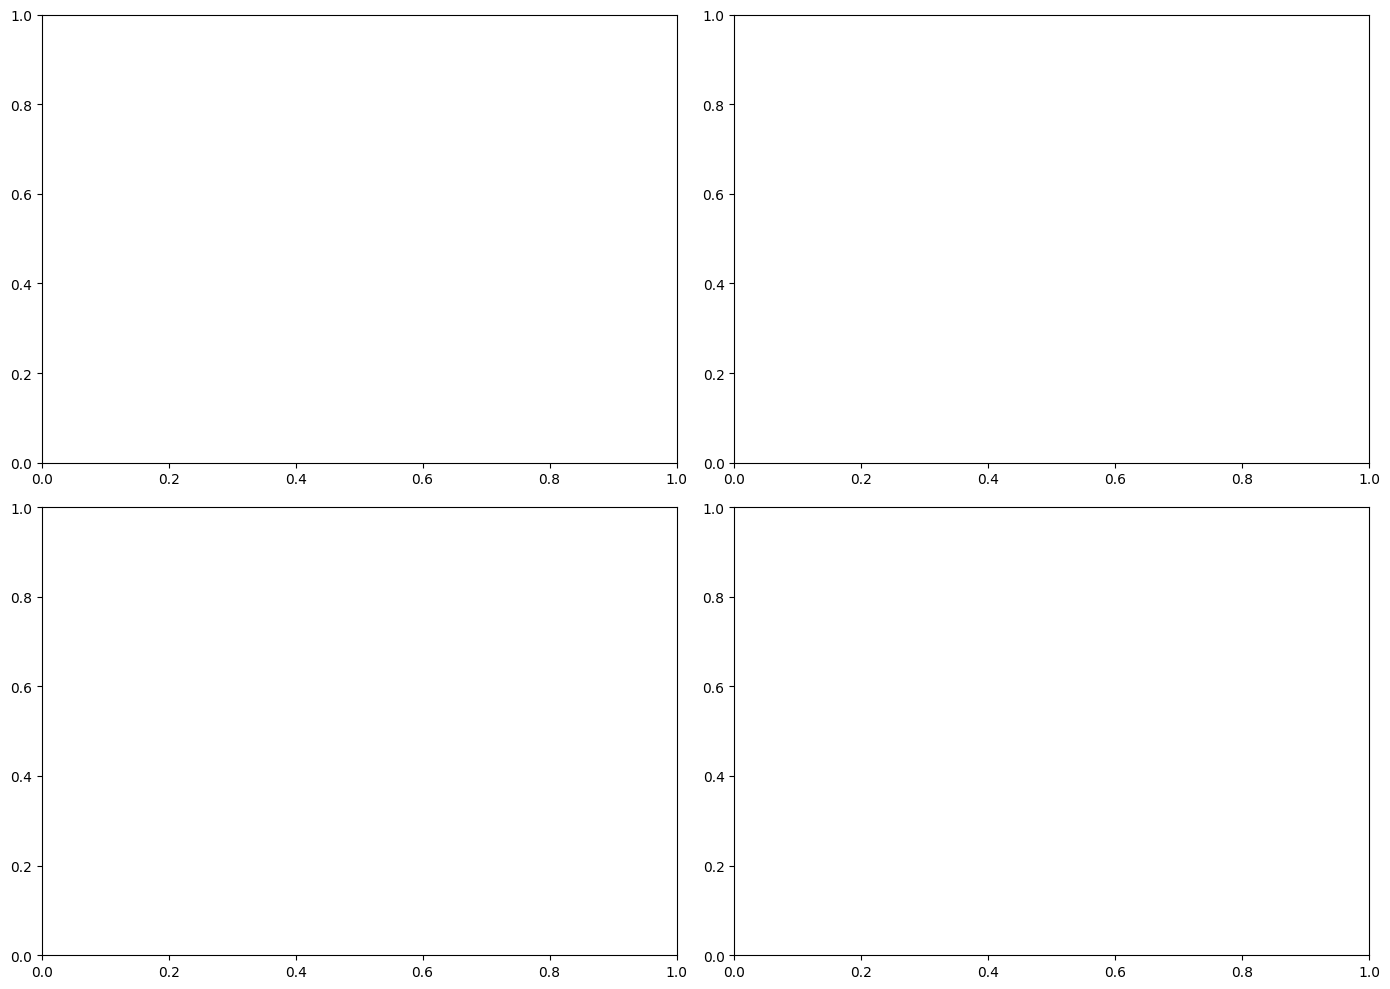

In [25]:
# Geo-Temporal Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Geographic heatmap by species (if seaborn is available)
if 'latitude' in features_df.columns and 'longitude' in features_df.columns:
    # Create a scatter plot with density
    valid_geo = features_df[(features_df['latitude'] != 0) & (features_df['longitude'] != 0)]
    if len(valid_geo) > 0:
        axes[0, 0].hexbin(valid_geo['longitude'], valid_geo['latitude'], 
                         gridsize=20, cmap='YlOrRd', mincnt=1)
        axes[0, 0].set_title('Geographic Density Heatmap', fontsize=11, fontweight='bold')
        axes[0, 0].set_xlabel('Longitude')
        axes[0, 0].set_ylabel('Latitude')

# 2. Temporal patterns by taxonomic class
taxa_to_analyze = features_df['class_name'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(taxa_to_analyze)))

if 'hour_of_day' in features_df.columns:
    for i, taxon in enumerate(taxa_to_analyze):
        taxon_data = features_df[features_df['class_name'] == taxon]
        valid_hours = taxon_data[taxon_data['hour_of_day'] >= 0]['hour_of_day']
        if len(valid_hours) > 0:
            hour_dist = valid_hours.value_counts().sort_index()
            # Normalize to proportions
            hour_dist = hour_dist / hour_dist.sum()
            axes[0, 1].plot(hour_dist.index, hour_dist.values, 
                           label=taxon, color=colors[i], marker='o', alpha=0.7)
    axes[0, 1].set_title('Hourly Activity Patterns by Taxon', fontsize=11, fontweight='bold')
    axes[0, 1].set_xlabel('Hour of Day')
    axes[0, 1].set_ylabel('Proportion of Recordings')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# 3. Monthly distribution by species (top 5 most common)
if 'month' in features_df.columns:
    top_species = features_df['primary_label'].value_counts().head(5).index
    for i, species in enumerate(top_species):
        species_data = features_df[features_df['primary_label'] == species]
        valid_months = species_data[species_data['month'] >= 0]['month']
        if len(valid_months) > 0:
            month_dist = valid_months.value_counts().sort_index()
            axes[1, 0].plot(month_dist.index, month_dist.values, 
                           label=species, marker='o', alpha=0.7)
    axes[1, 0].set_title('Monthly Distribution (Top 5 Species)', fontsize=11, fontweight='bold')
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Number of Recordings')
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)

# 4. Day of year patterns by taxon
if 'day_of_year' in features_df.columns:
    for i, taxon in enumerate(taxa_to_analyze):
        taxon_data = features_df[features_df['class_name'] == taxon]
        valid_days = taxon_data[taxon_data['day_of_year'] >= 0]['day_of_year']
        if len(valid_days) > 0:
            # Create binned distribution
            bins = np.linspace(1, 366, 12)
            counts, edges = np.histogram(valid_days, bins=bins)
            centers = (edges[:-1] + edges[1:]) / 2
            axes[1, 1].plot(centers, counts, label=taxon, 
                           color=colors[i], marker='o', alpha=0.7)
    axes[1, 1].set_title('Seasonal Patterns (Day of Year) by Taxon', fontsize=11, fontweight='bold')
    axes[1, 1].set_xlabel('Day of Year')
    axes[1, 1].set_ylabel('Number of Recordings')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'geo_temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Evolutionary Search Visualization

Detailed analysis of the genetic algorithm behavior and fitness landscape.

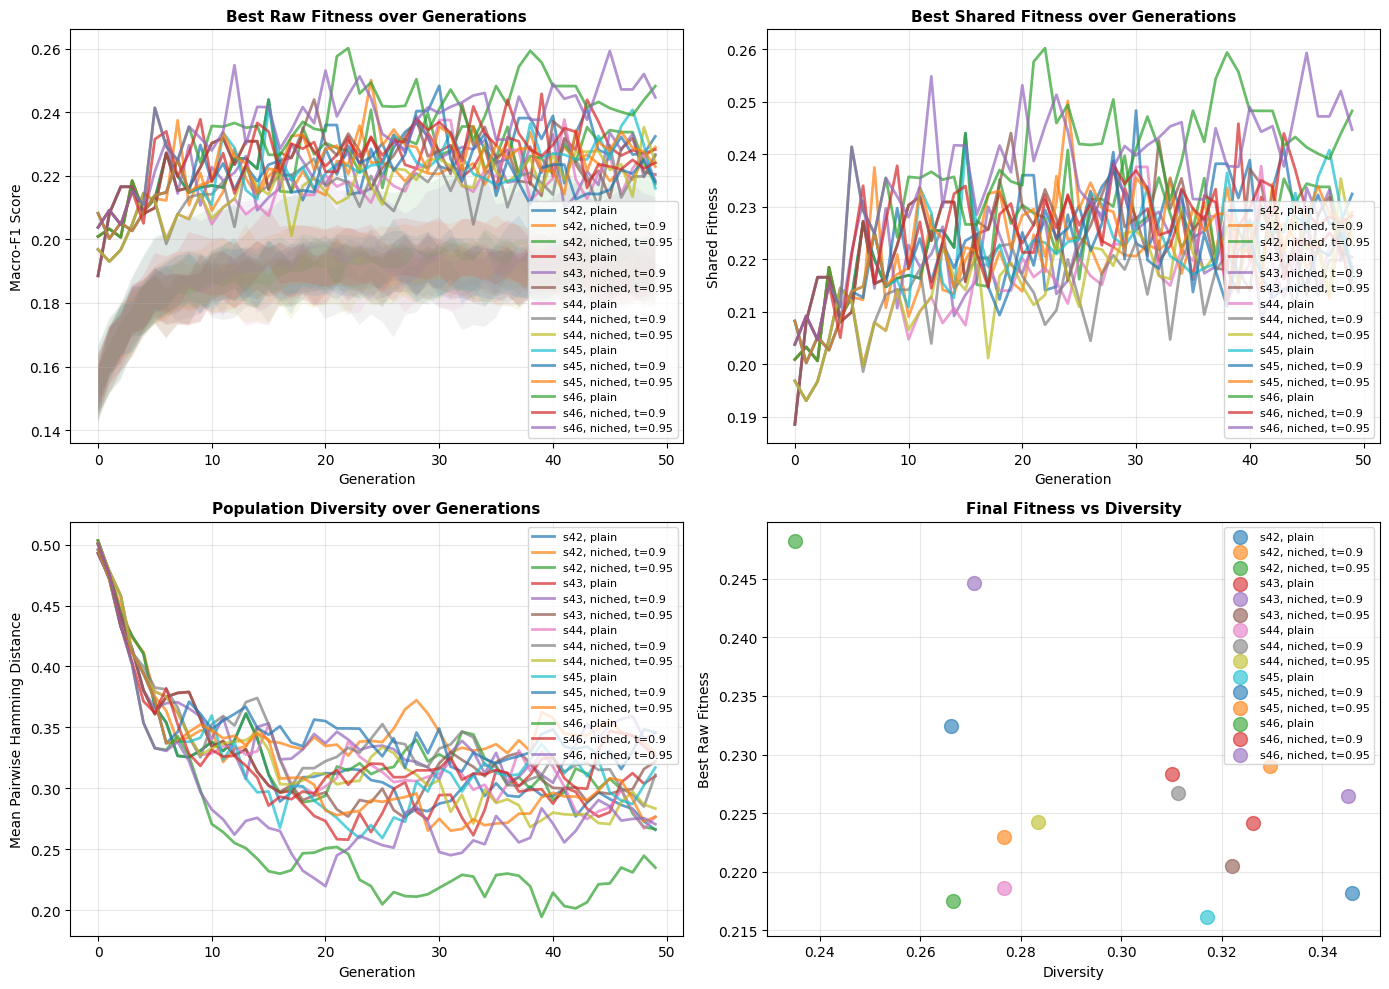

In [26]:
# GA Convergence Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for (seed, thresh, mode), entry in all_histories.items():
    h = pd.DataFrame(entry['history'])
    label = f"s{seed}, {mode}" + (f", t={thresh}" if thresh is not None else "")
    
    # Raw fitness evolution
    axes[0, 0].plot(h['generation'], h['best_raw'], label=label, alpha=0.7, linewidth=2)
    axes[0, 0].fill_between(h['generation'], h['mean_raw'] - h['mean_raw'].std(),
                            h['mean_raw'] + h['mean_raw'].std(), alpha=0.1)
    
    # Shared fitness (if available)
    if 'best_shared' in h.columns:
        axes[0, 1].plot(h['generation'], h['best_shared'], label=label, alpha=0.7, linewidth=2)
    
    # Diversity over time
    axes[1, 0].plot(h['generation'], h['diversity'], label=label, alpha=0.7, linewidth=2)
    
    # Fitness vs Diversity scatter (final generation)
    axes[1, 1].scatter(h['diversity'].iloc[-1], h['best_raw'].iloc[-1],
                       s=100, alpha=0.6, label=label)

axes[0, 0].set_title('Best Raw Fitness over Generations', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Generation')
axes[0, 0].set_ylabel('Macro-F1 Score')
axes[0, 0].legend(fontsize=8, loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Best Shared Fitness over Generations', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Generation')
axes[0, 1].set_ylabel('Shared Fitness')
axes[0, 1].legend(fontsize=8, loc='lower right')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Population Diversity over Generations', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Generation')
axes[1, 0].set_ylabel('Mean Pairwise Hamming Distance')
axes[1, 0].legend(fontsize=8, loc='best')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Final Fitness vs Diversity', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Diversity')
axes[1, 1].set_ylabel('Best Raw Fitness')
axes[1, 1].legend(fontsize=8, loc='best')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ga_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

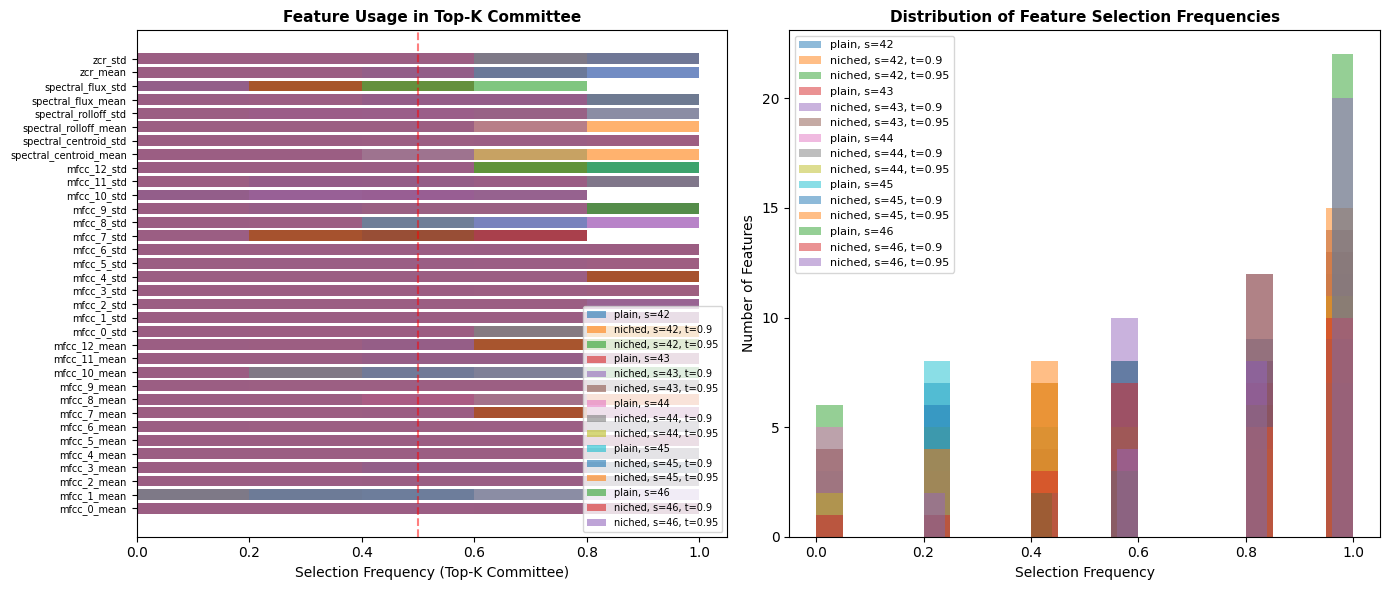

In [27]:
# Feature Selection Patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Extract top-k masks from final generation
for (seed, thresh, mode), entry in all_histories.items():
    if 'top_k_masks' in entry:
        masks = np.array(entry['top_k_masks'])
        feature_usage = masks.mean(axis=0)  # Fraction of committee using each feature
        
        label = f"{mode}, s={seed}" + (f", t={thresh}" if thresh is not None else "")
        axes[0].barh(range(len(feature_usage)), feature_usage, alpha=0.6, label=label)
        
        # Feature frequency distribution
        axes[1].hist(feature_usage, bins=20, alpha=0.5, label=label)

axes[0].set_yticks(range(len(FEATURE_COLS)))
axes[0].set_yticklabels(FEATURE_COLS, fontsize=7)
axes[0].set_xlabel('Selection Frequency (Top-K Committee)')
axes[0].set_title('Feature Usage in Top-K Committee', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=7, loc='lower right')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')

axes[1].set_xlabel('Selection Frequency')
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Distribution of Feature Selection Frequencies', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'feature_selection_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Performance Analysis

Per-species performance breakdown and confusion analysis.

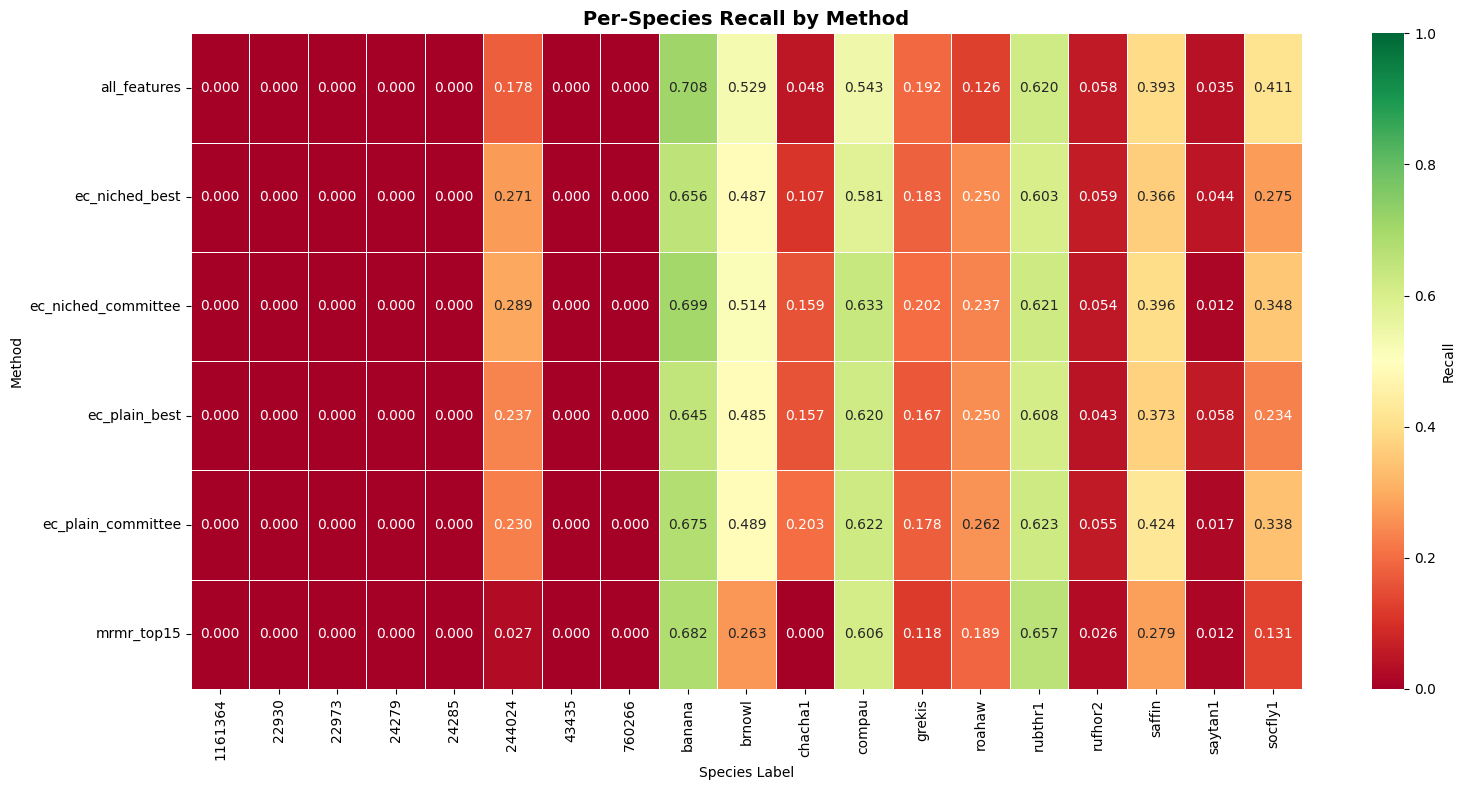


Best Method per Species:
  1161364: all_features (0.000)
  22930: all_features (0.000)
  22973: all_features (0.000)
  24279: all_features (0.000)
  24285: all_features (0.000)
  244024: ec_niched_committee (0.289)
  43435: all_features (0.000)
  760266: all_features (0.000)
  banana: all_features (0.708)
  brnowl: all_features (0.529)
  chacha1: ec_plain_committee (0.203)
  compau: ec_niched_committee (0.633)
  grekis: ec_niched_committee (0.202)
  roahaw: ec_plain_committee (0.262)
  rubthr1: mrmr_top15 (0.657)
  rufhor2: ec_niched_best (0.059)
  saffin: ec_plain_committee (0.424)
  saytan1: ec_plain_best (0.058)
  socfly1: all_features (0.411)


In [28]:
# Per-Species Performance Heatmap
if 'results_df' in locals() and len(results_df) > 0:
    recall_cols = [c for c in results_df.columns if c.startswith('recall_')]
    if recall_cols:
        plt.figure(figsize=(16, 8))
        
        # Pivot data for heatmap
        heatmap_data = results_df.groupby('method')[recall_cols].mean()
        heatmap_data.columns = [c.replace('recall_', '') for c in heatmap_data.columns]
        
        sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1,
                    fmt='.3f', linewidths=0.5, cbar_kws={'label': 'Recall'})
        plt.title('Per-Species Recall by Method', fontsize=14, fontweight='bold')
        plt.xlabel('Species Label')
        plt.ylabel('Method')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'per_species_recall_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Print best method per species
        print("\nBest Method per Species:")
        for species in heatmap_data.columns:
            best_method = heatmap_data[species].idxmax()
            best_score = heatmap_data[species].max()
            print(f"  {species}: {best_method} ({best_score:.3f})")

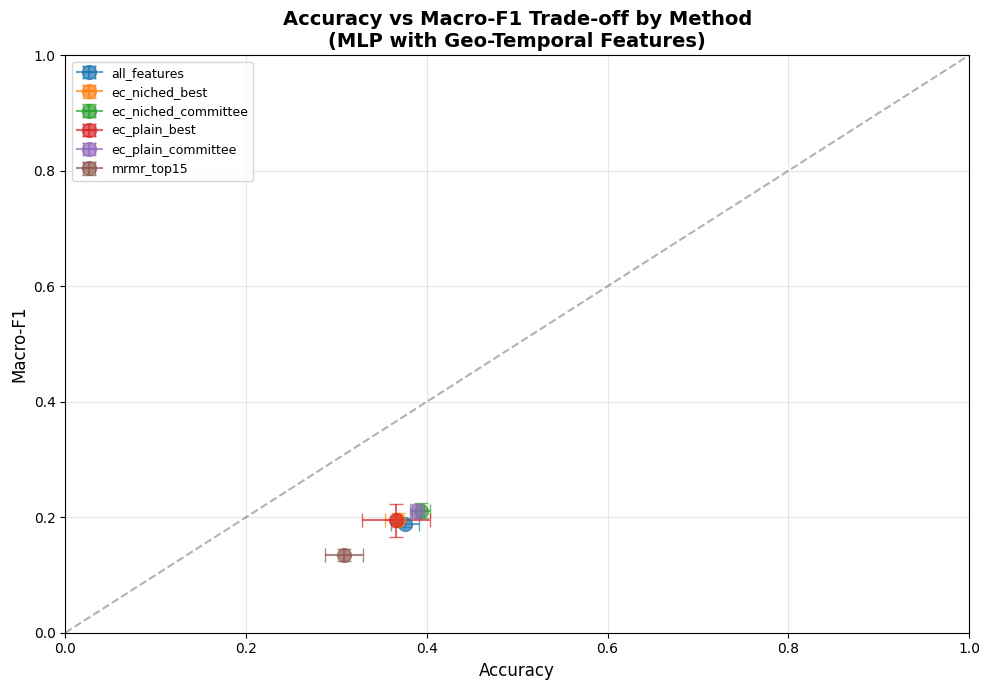

In [29]:
# Accuracy vs Macro-F1 Trade-off
if 'results_df' in locals() and len(results_df) > 0:
    plt.figure(figsize=(10, 7))
    
    # Group by method and calculate means
    method_stats = results_df.groupby('method')[['accuracy', 'macro_f1']].agg(['mean', 'std'])
    
    for method in method_stats.index:
        x = method_stats.loc[method, ('accuracy', 'mean')]
        y = method_stats.loc[method, ('macro_f1', 'mean')]
        xerr = method_stats.loc[method, ('accuracy', 'std')]
        yerr = method_stats.loc[method, ('macro_f1', 'std')]
        
        plt.errorbar(x, y, xerr=xerr, yerr=yerr, marker='o', markersize=10,
                     capsize=5, label=method, alpha=0.7)
    
    plt.xlabel('Accuracy', fontsize=12)
    plt.ylabel('Macro-F1', fontsize=12)
    plt.title('Accuracy vs Macro-F1 Trade-off by Method\n(MLP with Geo-Temporal Features)', fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    
    # Add diagonal reference line (balanced performance)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='balanced')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'accuracy_vs_f1_tradeoff.png', dpi=150, bbox_inches='tight')
    plt.show()

### Summary Statistics

Final summary of all visualizations and key metrics.

In [30]:
# Generate Summary Report
print("=" * 70)
print("VISUALIZATION SUMMARY - MLP with Geo-Temporal Features (PyTorch GPU-Accelerated)")
print("=" * 70)

print("\n📊 Data Distribution:")
print(f"  • Total clips: {len(manifest)}")
print(f"  • Windows extracted: {len(features_df)}")
print(f"  • Features per window: {len(FEATURE_COLS)}")
print(f"  • Species: {manifest['primary_label'].nunique()}")
print(f"  • Taxa: {manifest['class_name'].nunique()} (Aves, Insecta, Amphibia, Mammalia)")

print("\n🔧 MLP Configuration:")
print(f"  • Hidden layers: {MLP_HIDDEN}")
print(f"  • Solver: Adam (via PyTorch)")
print(f"  • Max iterations: {MLP_MAX_ITER}")

print("\n🚀 GPU Acceleration (PyTorch):")
print(f"  • GPU available: {GPU_AVAILABLE}")
if GPU_AVAILABLE:
    print(f"  • Device: {GPU_DEVICE}")
    print(f"  • GPU Name: {GPU_NAME}")
else:
    print("  • Using CPU (no GPU detected)")

print("\n🌍 Geo-Temporal Features (NEW):")
print(f"  • Geographic: latitude, longitude")
print(f"  • Temporal: hour_of_day, month, day_of_year (from URL timestamps)")

print("\n🧬 Evolutionary Search:")
print(f"  • Population size: {POP_SIZE}")
print(f"  • Generations: {N_GENERATIONS}")
print(f"  • Seeds run: {SEEDS}")
print(f"  • Niching thresholds: {THRESHOLDS}")

print("\n📁 Saved Figures:")
if FIGURES_DIR.exists():
    for fig_path in sorted(FIGURES_DIR.glob('*.png')):
        print(f"  • {fig_path.name}")
else:
    print("  (Figures directory will be created during execution)")

print("\n📈 Results Summary:")
if 'results_df' in locals() and len(results_df) > 0:
    best_method = results_df.groupby('method')['macro_f1'].mean().idxmax()
    best_f1 = results_df.groupby('method')['macro_f1'].mean().max()
    print(f"  • Best method: {best_method} (macro-F1: {best_f1:.3f})")
    print(f"  • Total result rows: {len(results_df)}")

print("\n" + "=" * 70)

VISUALIZATION SUMMARY - MLP with Geo-Temporal Features (PyTorch GPU-Accelerated)

📊 Data Distribution:
  • Total clips: 4170
  • Windows extracted: 26725
  • Features per window: 34
  • Species: 19
  • Taxa: 4 (Aves, Insecta, Amphibia, Mammalia)

🔧 MLP Configuration:
  • Hidden layers: (16,)
  • Solver: Adam (via PyTorch)
  • Max iterations: 200

🚀 GPU Acceleration (PyTorch):
  • GPU available: True
  • Device: cuda
  • GPU Name: Tesla T4

🌍 Geo-Temporal Features (NEW):
  • Geographic: latitude, longitude
  • Temporal: hour_of_day, month, day_of_year (from URL timestamps)

🧬 Evolutionary Search:
  • Population size: 50
  • Generations: 50
  • Seeds run: [42, 43, 44, 45, 46]
  • Niching thresholds: [0.9, 0.95]

📁 Saved Figures:
  • accuracy_vs_f1_tradeoff.png
  • comparison.png
  • data_distribution.png
  • ec_history.png
  • feature_by_species.png
  • feature_correlation.png
  • feature_distributions.png
  • feature_selection_patterns.png
  • ga_analysis.png
  • geo_temporal_analysis.p


FEATURE SELECTION ANALYSIS

📊 TOP 10 MOST SELECTED FEATURES:
--------------------------------------------------
   1. mfcc_4_std                      97.3% (73/75)
   2. mfcc_4_mean                     96.0% (72/75)
   3. mfcc_2_std                      96.0% (72/75)
   4. mfcc_5_mean                     94.7% (71/75)
   5. mfcc_1_std                      92.0% (69/75)
   6. mfcc_3_std                      88.0% (66/75)
   7. mfcc_6_std                      86.7% (65/75)
   8. mfcc_0_std                      85.3% (64/75)
   9. mfcc_5_std                      84.0% (63/75)
  10. spectral_centroid_std           84.0% (63/75)

📊 LEAST SELECTED FEATURES (Bottom 5):
--------------------------------------------------
   1. spectral_rolloff_std            42.7% (32/75)
   2. mfcc_10_std                     40.0% (30/75)
   3. mfcc_10_mean                    37.3% (28/75)
   4. spectral_flux_std               29.3% (22/75)
   5. mfcc_1_mean                     28.0% (21/75)


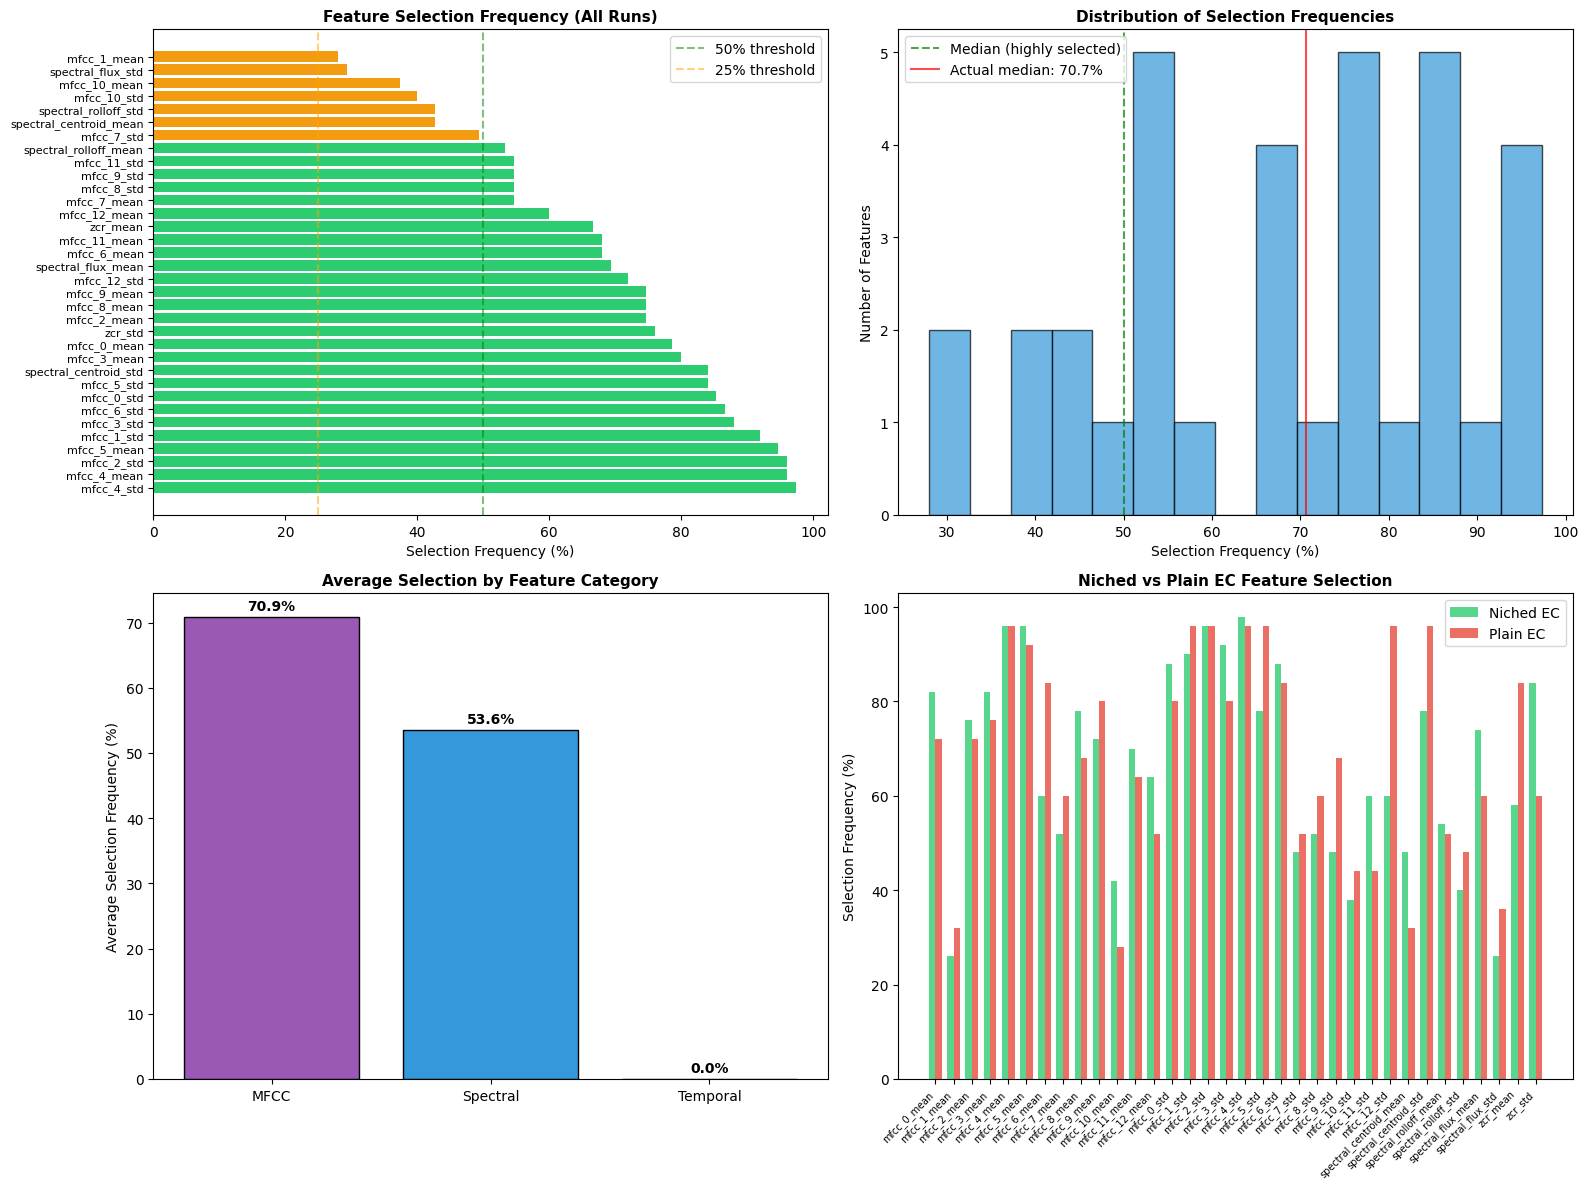


💾 Feature selection statistics saved to: /kaggle/working/results/runs/kaggle_mlp_geo_temporal_pytorch_n10_seeds5_thresh2_20260612_070414/feature_selection_statistics.csv

SUMMARY
  Total features: 34
  Features selected >50% of time: 27
  Features selected >25% of time: 34
  Features selected <10% of time: 0
  Average selection frequency: 67.9%
  Median selection frequency: 70.7%


In [31]:
# ==========================================
# DETAILED FEATURE SELECTION ANALYSIS
# ==========================================

print("\n" + "="*70)
print("FEATURE SELECTION ANALYSIS")
print("="*70)

# Aggregate feature selection across all runs
feature_selection_stats = {}

for feature in FEATURE_COLS:
    feature_selection_stats[feature] = {
        'total_selections': 0,
        'total_runs': 0,
        'selection_frequency': 0.0,
        'by_method': {}
    }

# Analyze selections from all_histories
for (seed, thresh, mode), entry in all_histories.items():
    if 'top_k_masks' in entry:
        masks = np.array(entry['top_k_masks'])  # Shape: (committee_size, n_features)
        method_name = f"{mode}_thresh{thresh}" if thresh else mode
        
        for i, feature in enumerate(FEATURE_COLS):
            # Count how many committee members selected this feature
            selections = masks[:, i].sum()
            feature_selection_stats[feature]['total_selections'] += int(selections)
            feature_selection_stats[feature]['total_runs'] += len(masks)
            
            if method_name not in feature_selection_stats[feature]['by_method']:
                feature_selection_stats[feature]['by_method'][method_name] = []
            feature_selection_stats[feature]['by_method'][method_name].append(float(selections / len(masks)))

# Calculate overall selection frequencies
for feature in FEATURE_COLS:
    stats = feature_selection_stats[feature]
    if stats['total_runs'] > 0:
        stats['selection_frequency'] = stats['total_selections'] / stats['total_runs']

# Sort features by selection frequency
sorted_features = sorted(
    feature_selection_stats.items(),
    key=lambda x: x[1]['selection_frequency'],
    reverse=True
)

# Display results
print("\n📊 TOP 10 MOST SELECTED FEATURES:")
print("-"*50)
for i, (feature, stats) in enumerate(sorted_features[:10]):
    freq = stats['selection_frequency'] * 100
    print(f"  {i+1:2d}. {feature:30s} {freq:5.1f}% ({stats['total_selections']}/{stats['total_runs']})")

print("\n📊 LEAST SELECTED FEATURES (Bottom 5):")
print("-"*50)
for i, (feature, stats) in enumerate(sorted_features[-5:]):
    freq = stats['selection_frequency'] * 100
    print(f"  {i+1:2d}. {feature:30s} {freq:5.1f}% ({stats['total_selections']}/{stats['total_runs']})")

# Create comprehensive feature selection visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Feature selection frequency bar chart
features = [f[0] for f in sorted_features]
frequencies = [f[1]['selection_frequency'] * 100 for f in sorted_features]
colors = ['#2ecc71' if f > 50 else '#f39c12' if f > 25 else '#e74c3c' for f in frequencies]

axes[0, 0].barh(range(len(features)), frequencies, color=colors)
axes[0, 0].set_yticks(range(len(features)))
axes[0, 0].set_yticklabels(features, fontsize=8)
axes[0, 0].set_xlabel('Selection Frequency (%)')
axes[0, 0].set_title('Feature Selection Frequency (All Runs)', fontsize=11, fontweight='bold')
axes[0, 0].axvline(x=50, color='green', linestyle='--', alpha=0.5, label='50% threshold')
axes[0, 0].axvline(x=25, color='orange', linestyle='--', alpha=0.5, label='25% threshold')
axes[0, 0].legend()

# 2. Selection frequency distribution
axes[0, 1].hist(frequencies, bins=15, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Selection Frequency (%)')
axes[0, 1].set_ylabel('Number of Features')
axes[0, 1].set_title('Distribution of Selection Frequencies', fontsize=11, fontweight='bold')
axes[0, 1].axvline(x=50, color='green', linestyle='--', alpha=0.7, label='Median (highly selected)')
median_freq = np.median(frequencies)
axes[0, 1].axvline(x=median_freq, color='red', linestyle='-', alpha=0.7, label=f'Actual median: {median_freq:.1f}%')
axes[0, 1].legend()

# 3. Feature category analysis
feature_categories = {
    'MFCC': [f for f in FEATURE_COLS if 'mfcc' in f],
    'Spectral': [f for f in FEATURE_COLS if 'spectral' in f],
    'Temporal': [f for f in FEATURE_COLS if any(x in f for x in ['zero_crossing', 'rms'])]
}

category_avg_freq = {}
for cat, cat_features in feature_categories.items():
    cat_freqs = [feature_selection_stats[f]['selection_frequency'] * 100 for f in cat_features if f in feature_selection_stats]
    category_avg_freq[cat] = np.mean(cat_freqs) if cat_freqs else 0

axes[1, 0].bar(category_avg_freq.keys(), category_avg_freq.values(),
               color=['#9b59b6', '#3498db', '#e74c3c'], edgecolor='black')
axes[1, 0].set_ylabel('Average Selection Frequency (%)')
axes[1, 0].set_title('Average Selection by Feature Category', fontsize=11, fontweight='bold')
for i, (cat, freq) in enumerate(category_avg_freq.items()):
    axes[1, 0].text(i, freq + 1, f'{freq:.1f}%', ha='center', fontweight='bold')

# 4. Compare niched vs plain selection patterns
niched_freqs = []
plain_freqs = []

for feature in FEATURE_COLS:
    niched_sum = 0
    niched_count = 0
    plain_sum = 0
    plain_count = 0
    
    for method, freqs in feature_selection_stats[feature]['by_method'].items():
        if 'niched' in method:
            niched_sum += sum(freqs)
            niched_count += len(freqs)
        elif 'plain' in method:
            plain_sum += sum(freqs)
            plain_count += len(freqs)
    
    if niched_count > 0:
        niched_freqs.append(niched_sum / niched_count * 100)
    if plain_count > 0:
        plain_freqs.append(plain_sum / plain_count * 100)

x = np.arange(len(FEATURE_COLS))
width = 0.35
axes[1, 1].bar(x - width/2, niched_freqs, width, label='Niched EC', color='#2ecc71', alpha=0.8)
axes[1, 1].bar(x + width/2, plain_freqs, width, label='Plain EC', color='#e74c3c', alpha=0.8)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(FEATURE_COLS, rotation=45, ha='right', fontsize=7)
axes[1, 1].set_ylabel('Selection Frequency (%)')
axes[1, 1].set_title('Niched vs Plain EC Feature Selection', fontsize=11, fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'detailed_feature_selection_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Save feature selection statistics to CSV
stats_df = pd.DataFrame([
    {
        'feature': feature,
        'selection_frequency': stats['selection_frequency'],
        'total_selections': stats['total_selections'],
        'total_runs': stats['total_runs'],
        'category': 'MFCC' if 'mfcc' in feature else 'Spectral' if 'spectral' in feature else 'Temporal'
    }
    for feature, stats in sorted_features
])
stats_df.to_csv(RUN_DIR / 'feature_selection_statistics.csv', index=False)
print(f"\n💾 Feature selection statistics saved to: {RUN_DIR / 'feature_selection_statistics.csv'}")

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"  Total features: {len(FEATURE_COLS)}")
print(f"  Features selected >50% of time: {sum(1 for f in frequencies if f > 50)}")
print(f"  Features selected >25% of time: {sum(1 for f in frequencies if f > 25)}")
print(f"  Features selected <10% of time: {sum(1 for f in frequencies if f < 10)}")
print(f"  Average selection frequency: {np.mean(frequencies):.1f}%")
print(f"  Median selection frequency: {np.median(frequencies):.1f}%")


In [32]:
%%writefile src/features.py
from __future__ import annotations

import re
import warnings
from datetime import datetime
from pathlib import Path

import librosa
import numpy as np
import pandas as pd

DEFAULT_SR = 22050
DEFAULT_WINDOW_SECONDS = 5.0
DEFAULT_N_MFCC = 13
DEFAULT_N_FFT = 2048
DEFAULT_HOP_LENGTH = 512


def feature_columns(n_mfcc: int = DEFAULT_N_MFCC) -> list[str]:
    """Return list of feature column names including audio and geo-temporal features."""
    audio_features = (
        [f"mfcc_{i}_mean" for i in range(n_mfcc)]
        + [f"mfcc_{i}_std" for i in range(n_mfcc)]
        + [
            "spectral_centroid_mean",
            "spectral_centroid_std",
            "spectral_rolloff_mean",
            "spectral_rolloff_std",
            "spectral_flux_mean",
            "spectral_flux_std",
            "zcr_mean",
            "zcr_std",
        ]
    )
    # NEW: Geo-temporal features
    geo_temporal_features = [
        "latitude",
        "longitude",
        "hour_of_day",
        "month",
        "day_of_year",
    ]
    return audio_features + geo_temporal_features


# Updated to include geo-temporal metadata columns
METADATA_COLUMNS = [
    "window_id",
    "clip_id",
    "primary_label",
    "common_name",
    "class_name",
    "split",
    "window_index",
    "latitude",       # NEW
    "longitude",      # NEW
    "hour_of_day",      # NEW
    "month",            # NEW
    "day_of_year",      # NEW
]


def extract_timestamp_from_url(url: str) -> datetime | None:
    """Extract Unix timestamp from URL query string and convert to datetime."""
    if pd.isna(url) or not url:
        return None
    match = re.search(r'\?(\d{10,13})', url)
    if match:
        timestamp = int(match.group(1))
        # Handle both seconds and milliseconds
        if timestamp > 1_000_000_000_000:  # Milliseconds
            timestamp = timestamp // 1000
        try:
            return datetime.fromtimestamp(timestamp)
        except (ValueError, OSError):
            return None
    return None


def extract_temporal_features(url: str) -> dict[str, float]:
    """Extract hour, month, and day_of_year from URL timestamp."""
    dt = extract_timestamp_from_url(url)
    if dt is None:
        return {"hour_of_day": -1, "month": -1, "day_of_year": -1}
    return {
        "hour_of_day": float(dt.hour),
        "month": float(dt.month),
        "day_of_year": float(dt.timetuple().tm_yday),
    }


def extract_features_for_clip(
    audio_path: Path,
    sr: int = DEFAULT_SR,
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    n_mfcc: int = DEFAULT_N_MFCC,
    n_fft: int = DEFAULT_N_FFT,
    hop_length: int = DEFAULT_HOP_LENGTH,
) -> list[dict]:
    y, _ = librosa.load(str(audio_path), sr=sr, mono=True)
    n_samples = int(window_seconds * sr)
    if len(y) < n_samples:
        return []

    out = []
    n_windows = len(y) // n_samples
    for i in range(n_windows):
        chunk = y[i * n_samples : (i + 1) * n_samples]
        feats = _features_for_window(chunk, sr, n_mfcc, n_fft, hop_length)
        feats["window_index"] = i
        out.append(feats)
    return out


def _features_for_window(
    y: np.ndarray, sr: int, n_mfcc: int, n_fft: int, hop_length: int
) -> dict:
    out: dict = {}

    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length
    )
    for i in range(n_mfcc):
        out[f"mfcc_{i}_mean"] = float(np.mean(mfcc[i]))
        out[f"mfcc_{i}_std"] = float(np.std(mfcc[i]))

    centroid = librosa.feature.spectral_centroid(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length
    )
    out["spectral_centroid_mean"] = float(np.mean(centroid))
    out["spectral_centroid_std"] = float(np.std(centroid))

    rolloff = librosa.feature.spectral_rolloff(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length
    )
    out["spectral_rolloff_mean"] = float(np.mean(rolloff))
    out["spectral_rolloff_std"] = float(np.std(rolloff))

    # Spectral flux: L2 norm of frame-to-frame differences in the magnitude
    # spectrum. librosa has no direct call, so compute from the STFT.
    spectrum = np.abs(librosa.stft(y=y, n_fft=n_fft, hop_length=hop_length))
    flux = np.linalg.norm(np.diff(spectrum, axis=1), axis=0)
    out["spectral_flux_mean"] = float(np.mean(flux))
    out["spectral_flux_std"] = float(np.std(flux))

    zcr = librosa.feature.zero_crossing_rate(
        y=y, frame_length=n_fft, hop_length=hop_length
    )
    out["zcr_mean"] = float(np.mean(zcr))
    out["zcr_std"] = float(np.std(zcr))

    return out


def extract_all(
    manifest: pd.DataFrame,
    raw_data_dir: Path,
    audio_subdir: str = "train_audio",
    progress: bool = True,
    sr: int = DEFAULT_SR,
    window_seconds: float = DEFAULT_WINDOW_SECONDS,
    n_mfcc: int = DEFAULT_N_MFCC,
    n_fft: int = DEFAULT_N_FFT,
    hop_length: int = DEFAULT_HOP_LENGTH,
) -> pd.DataFrame:
    audio_root = Path(raw_data_dir) / audio_subdir
    iterator = list(manifest.itertuples(index=False))

    if progress:
        from tqdm.auto import tqdm

        iterator = tqdm(iterator, desc="Extracting features")

    rows: list[dict] = []
    skipped: list[str] = []
    for row in iterator:
        path = audio_root / row.filename
        try:
            window_feats = extract_features_for_clip(
                path,
                sr=sr,
                window_seconds=window_seconds,
                n_mfcc=n_mfcc,
                n_fft=n_fft,
                hop_length=hop_length,
            )
        except Exception as exc:
            warnings.warn(f"Failed to load {row.filename}: {exc}")
            skipped.append(row.clip_id)
            continue
        if not window_feats:
            skipped.append(row.clip_id)
            continue

        # Extract temporal features from URL
        temporal_feats = extract_temporal_features(getattr(row, "url", ""))

        for w in window_feats:
            w["clip_id"] = row.clip_id
            w["primary_label"] = row.primary_label
            w["common_name"] = row.common_name
            w["class_name"] = row.class_name
            w["split"] = row.split
            w["window_id"] = f"{row.clip_id}_w{w['window_index']}"
            # Add geo-temporal features from manifest
            w["latitude"] = float(getattr(row, "latitude", 0.0))
            w["longitude"] = float(getattr(row, "longitude", 0.0))
            w["hour_of_day"] = temporal_feats["hour_of_day"]
            w["month"] = temporal_feats["month"]
            w["day_of_year"] = temporal_feats["day_of_year"]
            rows.append(w)

    if skipped:
        warnings.warn(
            f"Skipped {len(skipped)} clips (shorter than {window_seconds}s "
            f"or failed to load)"
        )

    df = pd.DataFrame(rows)
    return df[METADATA_COLUMNS + feature_columns(n_mfcc)]

Overwriting src/features.py
